# 02 · Hierarchical Naive Bayes follow-up · clusters fusionados C5–C8

This notebook consumes the handoff created by `01_modeling_clustering.ipynb`.
If the handoff is not available in the current project, the initialization cell
can recover it from an earlier ENSANUT project or from editable external paths.
Evidence is calculated for the primary and secondary dictionary groups across
all Leiden microclusters simultaneously. This is not a predictive evaluation.


This notebook uses the complete variable set that passes the NB heatmap filter. It does not apply a top-20 or top-100 predictor restriction.


## 1. Initialization and handoff loading

In [1]:
from pathlib import Path
import importlib
import json
import shutil
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
    set_matplotlib_formats("svg")
except Exception:
    pass

_current = Path.cwd().expanduser().resolve()
PROJECT_ROOT = next(
    (
        candidate for candidate in [_current, *_current.parents]
        if (candidate / "src" / "ensanut_hba1c").is_dir()
        and (candidate / "data" / "input").is_dir()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("The project root could not be located.")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Remove stale package versions retained by an existing notebook kernel.
for _module_name in list(sys.modules):
    if _module_name == "ensanut_hba1c" or _module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(_module_name, None)
importlib.invalidate_caches()

from ensanut_hba1c.paths import ProjectPaths
from ensanut_hba1c.io import load_notebook_handoff

PATHS = ProjectPaths(PROJECT_ROOT).ensure()
HANDOFF_DIR = PATHS.handoff_dir
OUTPUT_DIR = PATHS.notebook2_results

# Normally these paths should remain None. Use them only when the cluster
# dataset or dictionary is stored outside the current project.
EXTERNAL_CLUSTER_DATASET_PATH = None
EXTERNAL_DICTIONARY_PATH = None

AUTO_DISCOVER_PREVIOUS_HANDOFF = True
HANDOFF_SEARCH_ROOTS = [PROJECT_ROOT.parent, PROJECT_ROOT.parent.parent]
HANDOFF_SEARCH_MAX_DEPTH = 5
PERSIST_RECOVERED_HANDOFF = True

fallback_cluster_paths = [
    PATHS.notebook1_results / "complete_cluster_dataset.pkl",
    PATHS.notebook1_results / "complete_cluster_dataset.csv",
]
fallback_dictionary_paths = [PATHS.input_dir / "ENSANUT_2024.csv"]
if EXTERNAL_CLUSTER_DATASET_PATH is not None:
    fallback_cluster_paths.insert(0, Path(EXTERNAL_CLUSTER_DATASET_PATH).expanduser())
if EXTERNAL_DICTIONARY_PATH is not None:
    fallback_dictionary_paths.insert(0, Path(EXTERNAL_DICTIONARY_PATH).expanduser())

cluster_df, data_dictionary_df, handoff_metadata, handoff_sources = load_notebook_handoff(
    HANDOFF_DIR,
    fallback_cluster_paths=fallback_cluster_paths,
    fallback_dictionary_paths=fallback_dictionary_paths,
    auto_discover_search_roots=(HANDOFF_SEARCH_ROOTS if AUTO_DISCOVER_PREVIOUS_HANDOFF else []),
    auto_discover_max_depth=HANDOFF_SEARCH_MAX_DEPTH,
    persist_recovered_handoff=PERSIST_RECOVERED_HANDOFF,
    cluster_column="Cluster_SHAP",
)

CLUSTER_COLUMN = "Cluster_SHAP"

RUN_CONTEXT = pd.DataFrame([{
    "cluster_rows": len(cluster_df),
    "dictionary_rows": len(data_dictionary_df),
    "n_clusters": cluster_df[CLUSTER_COLUMN].nunique(dropna=True),
    "cluster_source": str(handoff_sources["cluster"]),
    "dictionary_source": str(handoff_sources["dictionary"]),
}])
display(RUN_CONTEXT)





,cluster_rows,dictionary_rows,n_clusters,cluster_source,dictionary_source
0,2530,2695,10,/Users/cristianjuliocesarpadronmanrique/Deskto...,/Users/cristianjuliocesarpadronmanrique/Deskto...


## 2. Editable Naive Bayes evidence parameters

In [2]:
RUN_SIGNED_EVIDENCE_ANALYSIS = True
RUN_PRIMARY_LEVEL = True
RUN_SECONDARY_LEVEL = True

BAYES_N_BINS = 10
BAYES_ALPHA = 1.0
BAYES_MIN_CASES = 20
BAYES_EPSILON_THRESHOLD = 1.96
BAYES_FORCE_EXACT_FEATURE_BINS = False
MAX_INFERRED_CATEGORIES = 50
MINIMUM_VARIABLES_PER_GROUP = 2
TOP_RULES_PER_CLUSTER = 10

# Publication-workbook thresholds.
EXPORT_MIN_NX = 40
EXPORT_MIN_N_CLUSTER_X = 40
EXPORT_MIN_SCORE = 0.5

SELECTED_PRIMARY_GROUPS = None
SELECTED_SECONDARY_GROUPS = None

SHOW_PROGRESS_BAR = True
PROGRESS_LEAVE = True
PROGRESS_MININTERVAL = 0.25
SAVE_GROUP_FIGURES = False
SAVE_TOP_RULE_TABLES = True

## 3. Editable PyComplexHeatmap parameters

In [3]:
RUN_COMPLEX_HEATMAPS = True
PUBLICATION_DPI = 600
HEATMAP_LANGUAGE = "en"
HEATMAP_FONT_FAMILY = "DejaVu Sans"

POSITIVE_CMAP = "Reds"
NEGATIVE_CMAP = "Blues"
NET_CMAP = "RdBu_r"
ROBUST_COLOR_PERCENTILE = 95.0
GENERATE_NET_HEATMAP = True
SHOW_CELL_VALUES = False
HEATMAP_RASTERIZED = False

PANEL_WIDTH_INCHES = 1.0
ROW_HEIGHT_INCHES = 0.10
MINIMUM_FIGURE_HEIGHT = 4.0
MAXIMUM_FIGURE_HEIGHT = 26.0
COLUMN_GAP_MM = 8.0
ROW_SPLIT_GAP_MM = 1.2

ROW_LABEL_FONTSIZE = 7.5
COLUMN_LABEL_FONTSIZE = 8.0
TITLE_FONTSIZE = 13.0
PANEL_TITLE_FONTSIZE = 10.5
CLUSTER_ANNOTATION_FONTSIZE = 7.0
SHOW_FIGURE_TITLE = False
SHOW_PANEL_TITLES = False

SHOW_CLUSTER_SIZE_ANNOTATION = True
SHOW_CLUSTER_STRIP_ANNOTATION = True
SHOW_BOTTOM_CLUSTER_NUMBERS = True
SHOW_PRIMARY_ROW_ANNOTATION = True
PRIMARY_ROW_ANNOTATION_CMAP = "tab20"
PRIMARY_ROW_ANNOTATION_WIDTH_MM = 5.0
PRIMARY_ROW_ANNOTATION_LEGEND = True
PRIMARY_ROW_ANNOTATION_LEGEND_MAX_COLUMNS = 4

CLUSTER_ROWS = True
CLUSTER_COLUMNS = True
CLUSTERING_BASIS = "combined"       # combined | positive | negative | net
CLUSTERING_METRIC = "correlation"
CLUSTERING_METHOD = "average"
CLUSTER_SECONDARY_WITHIN_PRIMARY = True
ROW_DENDROGRAM = False
COLUMN_DENDROGRAM = False


## 4. Editable exclusions applied before any calculation

Two visible exclusion lists are used:

1. `NB_FRAMEWORK_EXCLUDE_VARIABLES`: permanent scientific exclusions from the NB framework.
2. `NOTEBOOK2_EXCLUDE_VARIABLES`: additional or temporary exclusions for Notebook 2.

Both lists are applied before binning, NB score calculation, epsilon calculation,
heatmap generation, and table export.


In [4]:
ID_COLUMNS = ["FOLIO_I", "FOLIO_INT"]
TARGET_COLUMN = []  # The cluster is defined by CLUSTER_COLUMN; HbA1c is not a predictor.

# -----------------------------------------------------------------------------
# MANDATORY SCIENTIFIC EXCLUSIONS
# These columns cannot enter binning, NB scoring, coverage, heatmaps, or
# the final XGBoost model. Separate lists keep the audit explicit and
# provide a second safety barrier at the final stage.
# -----------------------------------------------------------------------------
REDUNDANT_AGE_COLUMNS = [
    "gpoedad", "annac", "mesnac", "fecha_nacimiento", "H0304A", "H0304M",
    "FECH_NAC", "edad", "AEDAD", "A0302", "MESES",
]

TARGET_DERIVED_COLUMNS = [
    "hba1c_class_cat", "hba1c_class_bin", "clasif_hba1c_cat", "clasif_hba1c_bin",
    "preferred_combined_class_bin", "preferred_combined_class_cat",
    "clasif_combinada_pref_bin", "clasif_combinada_pref_cat",
    "HbA1c_Status", "Estado_HbA1c",
]

# Additional direct-leakage variables excluded from the framework.
DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS = [
    "HB1AC",
    #"GLU_SUERO",
    "Metabolic_Syndrome_Status",
]

# -----------------------------------------------------------------------------
# LIST 1: variables excluded from the Naive Bayes framework.
# Excluded before binning, counts, score, epsilon, coverage, heatmaps,
# and Excel exports.
# -----------------------------------------------------------------------------
NB_FRAMEWORK_EXCLUDE_VARIABLES = sorted(set(
    DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
    + TARGET_DERIVED_COLUMNS
    + REDUNDANT_AGE_COLUMNS
))

# -----------------------------------------------------------------------------
# LIST 2: additional variables not processed in Notebook 2.
# Leave empty or add codes exactly as they appear in cluster_df.
# Example: "VAR001", "VAR002"
# -----------------------------------------------------------------------------
NOTEBOOK2_EXCLUDE_VARIABLES = [
    # "VAR001",
]

# Automatic exclusions for identifiers, technical representations, and macroclusters.
AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS = [
    *ID_COLUMNS,
    "Cluster_SHAP_macro",
    *[
        column for column in cluster_df.columns
        if column.startswith("PCA_")
        or column.startswith("UMAP_VISUAL_")
        or column.startswith("UMAP_GRAPH_PHATE_")
        or column.startswith("Mellon_")
    ],
]

BAYES_EXCLUDE_COLUMNS = sorted(set(
    NB_FRAMEWORK_EXCLUDE_VARIABLES
    + NOTEBOOK2_EXCLUDE_VARIABLES
    + AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS
))

eligible_variables = sorted(
    set(cluster_df.columns)
    .difference(BAYES_EXCLUDE_COLUMNS)
    .difference({CLUSTER_COLUMN})
)

# Explicit audit of each exclusion source and its presence in the dataset.
exclusion_source = {}
for variable in DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Direct outcome/leakage")
for variable in TARGET_DERIVED_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Target-derived")
for variable in REDUNDANT_AGE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Redundant/derived age")
for variable in NOTEBOOK2_EXCLUDE_VARIABLES:
    exclusion_source.setdefault(str(variable), []).append("Notebook 2")
for variable in AUTOMATIC_NOTEBOOK2_EXCLUDE_COLUMNS:
    exclusion_source.setdefault(str(variable), []).append("Automatic/technical")

exclusion_audit = pd.DataFrame([
    {
        "var": variable,
        "exclusion_source": " + ".join(sources),
        "present_in_cluster_df": variable in cluster_df.columns,
        "processed_by_nb": False,
    }
    for variable, sources in sorted(exclusion_source.items())
])
exclusion_audit.to_csv(
    OUTPUT_DIR / "notebook2_variable_exclusions.csv",
    index=False,
)

print("Total variables in cluster_df:", cluster_df.shape[1])
print("Excluded variables:", len(BAYES_EXCLUDE_COLUMNS))
print("NB-eligible variables:", len(eligible_variables))
display(exclusion_audit)


Total variables in cluster_df: 2765
Excluded variables: 80
NB-eligible variables: 2697


,var,exclusion_source,present_in_cluster_df,processed_by_nb
0,A0302,Redundant/derived age,True,False
1,AEDAD,Redundant/derived age,True,False
2,Cluster_SHAP_macro,Automatic/technical,True,False
3,Estado_HbA1c,Target-derived,False,False
4,FECH_NAC,Redundant/derived age,True,False
...,...,...,...,...
75,hba1c_class_bin,Target-derived,False,False
76,hba1c_class_cat,Target-derived,False,False
77,mesnac,Redundant/derived age,False,False
78,preferred_combined_class_bin,Target-derived,False,False


## 5. Data-dictionary hierarchy

In [5]:
from ensanut_hba1c.bayes.hierarchy import hierarchy_tree_text, parse_dictionary_hierarchy

(
    dictionary_hierarchy_df,
    dictionary_hierarchy_summary,
    PRIMARY_VARIABLE_GROUPS,
    SECONDARY_VARIABLE_GROUPS,
) = parse_dictionary_hierarchy(data_dictionary_df)

eligible_set = set(eligible_variables)
PRIMARY_VARIABLE_GROUPS = {
    group: sorted(set(variables).intersection(eligible_set))
    for group, variables in PRIMARY_VARIABLE_GROUPS.items()
}
SECONDARY_VARIABLE_GROUPS = {
    group: sorted(set(variables).intersection(eligible_set))
    for group, variables in SECONDARY_VARIABLE_GROUPS.items()
}
print(hierarchy_tree_text(dictionary_hierarchy_summary))
display(dictionary_hierarchy_summary)


/opt/anaconda3/envs/ensanut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


■ ACTIVIDAD FISICA
  ├── MODULO ACTIVIDAD FISICA ADULTOS (30 variables; 30 rows)
  └── MODULO ACTIVIDAD FISICA NIÑOS (38 variables; 38 rows)

■ AGREGACIÓN POR GRUPOS NUTRICIONALES
  └── (sin subnivel) (29 variables; 29 rows)

■ ANTROPOMETRÍA Y PRESIÓN ARTERIAL
  └── (sin subnivel) (11 variables; 11 rows)

■ ENF
  └── CRÓNICAS (10 variables; 10 rows)

■ ETIQUETADO FRONTAL
  └── (sin subnivel) (87 variables; 87 rows)

■ FRECUENCIA DE ALIMENTOS
  └── (sin subnivel) (277 variables; 277 rows)

■ HEMOGLOBINA
  └── (sin subnivel) (2 variables; 2 rows)

■ HOGAR
  ├── I CARACTERÍSTICAS DE LA VIVIENDA (24 variables; 24 rows)
  ├── II IDENTIFICACIÓN DE HOGARES (4 variables; 4 rows)
  ├── III CARACTERÍSTICAS SOCIODEMOGRÁFICAS (1 variables; 1 rows)
  ├── IV SITUACIÓN DE SALUD Y UTILIZACIÓN DE SERVICIOS DE SALUD (3 variables; 3 rows)
  ├── MODULO HOGAR (11 variables; 11 rows)
  ├── V OTRAS CARACTERÍSTICAS DEL HOGAR (20 variables; 20 rows)
  ├── VII SEGURIDAD ALIMENTARIA (16 variables; 16 rows)
  └──

,nivel_primario,nivel_secundario,ruta_jerarquica,n_filas,n_variables_unicas
0,ACTIVIDAD FISICA,MODULO ACTIVIDAD FISICA ADULTOS,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,30,30
1,ACTIVIDAD FISICA,MODULO ACTIVIDAD FISICA NIÑOS,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA NIÑOS,38,38
2,AGREGACIÓN POR GRUPOS NUTRICIONALES,(sin subnivel),AGREGACIÓN POR GRUPOS NUTRICIONALES,29,29
3,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,(sin subnivel),ANTROPOMETRÍA Y PRESIÓN ARTERIAL,11,11
4,ENF,CRÓNICAS,ENF > CRÓNICAS,10,10
...,...,...,...,...,...
64,SERVICIOS SALUD,(sin subnivel),SERVICIOS SALUD,12,12
65,SERVICIOS SALUD,I UTILIZACIÓN,SERVICIOS SALUD > I UTILIZACIÓN,2,2
66,SERVICIOS SALUD,II ATENCIÓN,SERVICIOS SALUD > II ATENCIÓN,36,36
67,SERVICIOS SALUD,III MEDICAMENTOS,SERVICIOS SALUD > III MEDICAMENTOS,9,9


## 6. Calculate positive and negative evidence

In [6]:
import importlib
import inspect

# Mandatory reload: avoids stale kernels that retained an earlier
# SignedEvidenceConfig without the export-threshold parameters.
for _module_name in list(sys.modules):
    if _module_name == "ensanut_hba1c" or _module_name.startswith("ensanut_hba1c."):
        sys.modules.pop(_module_name, None)
importlib.invalidate_caches()

import ensanut_hba1c.bayes.hierarchy as bayes_hierarchy
bayes_hierarchy = importlib.reload(bayes_hierarchy)

module_path = Path(bayes_hierarchy.__file__).resolve()
expected_module_path = (SRC_DIR / "ensanut_hba1c" / "bayes" / "hierarchy.py").resolve()
if module_path != expected_module_path:
    raise RuntimeError(
        "ensanut_hba1c was imported from a different project path. "
        f"Imported path: {module_path}. Expected path: {expected_module_path}. "
        "Restart the kernel and run Notebook 2 from the first cell."
    )

SignedEvidenceConfig = bayes_hierarchy.SignedEvidenceConfig
run_hierarchical_signed_evidence_analysis = bayes_hierarchy.run_hierarchical_signed_evidence_analysis

required_export_parameters = {"export_min_nx", "export_min_n_cluster_x", "export_min_score"}
available_config_parameters = set(inspect.signature(SignedEvidenceConfig).parameters)
missing_export_parameters = required_export_parameters.difference(available_config_parameters)
if missing_export_parameters:
    raise RuntimeError(
        "SignedEvidenceConfig is outdated and does not contain: "
        f"{sorted(missing_export_parameters)}. Loaded module: {module_path}"
    )

print("Loaded NB module:", module_path)
print("Verified export parameters:", sorted(required_export_parameters))

SUMMARY_PATH = OUTPUT_DIR / "signed_evidence_all_groups.csv"
COVERAGE_PATH = OUTPUT_DIR / "group_coverage.csv"

if RUN_SIGNED_EVIDENCE_ANALYSIS:
    SIGNED_CONFIG = SignedEvidenceConfig(
        n_bins_features=BAYES_N_BINS,
        alpha=BAYES_ALPHA,
        min_cases=BAYES_MIN_CASES,
        epsilon_threshold=BAYES_EPSILON_THRESHOLD,
        force_exact_feature_bins=BAYES_FORCE_EXACT_FEATURE_BINS,
        max_inferred_categories=MAX_INFERRED_CATEGORIES,
        minimum_variables_per_group=MINIMUM_VARIABLES_PER_GROUP,
        top_rules_per_cluster=TOP_RULES_PER_CLUSTER,
        publication_dpi=PUBLICATION_DPI,
        show_progress_bar=SHOW_PROGRESS_BAR,
        progress_leave=PROGRESS_LEAVE,
        progress_mininterval=PROGRESS_MININTERVAL,
        save_group_figures=SAVE_GROUP_FIGURES,
        save_top_rule_tables=SAVE_TOP_RULE_TABLES,
        save_complex_heatmaps=False,
        complex_heatmap_robust_percentile=ROBUST_COLOR_PERCENTILE,
        export_min_nx=EXPORT_MIN_NX,
        export_min_n_cluster_x=EXPORT_MIN_N_CLUSTER_X,
        export_min_score=EXPORT_MIN_SCORE,
    )
    signed_results = run_hierarchical_signed_evidence_analysis(
        cluster_df=cluster_df,
        dictionary_df=data_dictionary_df,
        output_dir=OUTPUT_DIR,
        cluster_column=CLUSTER_COLUMN,
        excluded_columns=BAYES_EXCLUDE_COLUMNS,
        run_primary_level=RUN_PRIMARY_LEVEL,
        run_secondary_level=RUN_SECONDARY_LEVEL,
        config=SIGNED_CONFIG,
        selected_primary_groups=SELECTED_PRIMARY_GROUPS,
        selected_secondary_groups=SELECTED_SECONDARY_GROUPS,
    )
    weighted_summary = signed_results["summary"].copy()
    group_coverage = signed_results["coverage"].copy()
    filtered_rules = signed_results["filtered_rules_table"].copy()
    print("Main workbook with coverage:", signed_results["workbook_path"])
    print("Workbook containing all variables:", signed_results["all_variables_workbook_path"])
    print("Single workbook containing all row-level operations:", signed_results["internal_operations_workbook_path"])
    print("Filtered rules in the main workbook:", len(filtered_rules))
else:
    weighted_summary = pd.read_csv(SUMMARY_PATH)
    group_coverage = pd.read_csv(COVERAGE_PATH) if COVERAGE_PATH.is_file() else pd.DataFrame()

display(group_coverage)
display(weighted_summary.head(150))

Loaded NB module: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/src/ensanut_hba1c/bayes/hierarchy.py
Verified export parameters: ['export_min_n_cluster_x', 'export_min_nx', 'export_min_score']


Primary/secondary Bayes evidence: 100%|█| 85/85 [00:13<00:00,  6.48group/s, sec


Main workbook with coverage: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/hierarchical_signed_bayes_evidence.xlsx
Workbook containing all variables: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/hierarchical_signed_bayes_evidence_all_variables.xlsx
Single workbook containing all row-level operations: /Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/bayes_internal_operations_all_variables.xlsx
Filtered rules in the main workbook: 1405


,level,group,n_requested_variables,n_usable_variables,n_encoded_variables,n_binary_rules,n_clusters,status,reason
0,primary,ACTIVIDAD FISICA,68,68,30.0,222.0,10.0,completed,
1,primary,AGREGACIÓN POR GRUPOS NUTRICIONALES,28,28,28.0,243.0,10.0,completed,
2,primary,ANTROPOMETRÍA Y PRESIÓN ARTERIAL,11,11,11.0,93.0,10.0,completed,
3,primary,ENF,9,9,9.0,90.0,10.0,completed,
4,primary,ETIQUETADO FRONTAL,87,87,72.0,421.0,10.0,completed,
...,...,...,...,...,...,...,...,...,...
80,secondary,SERVICIOS SALUD,8,8,7.0,63.0,10.0,completed,
81,secondary,SERVICIOS SALUD > I UTILIZACIÓN,2,2,2.0,5.0,10.0,completed,
82,secondary,SERVICIOS SALUD > II ATENCIÓN,36,36,34.0,345.0,10.0,completed,
83,secondary,SERVICIOS SALUD > III MEDICAMENTOS,9,9,6.0,24.0,10.0,completed,


,analysis_scope,level,group,cluster,n_participants,n_cluster_members,n_rest,n_group_variables,n_encoded_variables,n_binary_rules,...,member_positive_contribution_sum,member_negative_contribution_sum_signed,member_negative_contribution_sum_abs,member_net_contribution_sum,rest_positive_contribution_sum,rest_negative_contribution_sum_signed,rest_negative_contribution_sum_abs,rest_net_contribution_sum,encoding_passes,clusters_computed_simultaneously
0,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,0,2530,457,2073,68,30,222,...,244.867211,-501.037224,501.037224,-256.170013,856.045167,-3380.525912,3380.525912,-2524.480745,1,10
1,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,1,2530,421,2109,68,30,222,...,239.813014,-646.731373,646.731373,-406.918360,855.339298,-5589.584587,5589.584587,-4734.245288,1,10
2,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,2,2530,361,2169,68,30,222,...,1155.759989,-98.862872,98.862872,1056.897117,4500.007757,-968.212612,968.212612,3531.795145,1,10
3,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,3,2530,340,2190,68,30,222,...,1404.365996,-83.352034,83.352034,1321.013962,5575.353021,-1109.058822,1109.058822,4466.294199,1,10
4,descriptive_weighted_signed_bayes_evidence_ful...,primary,ACTIVIDAD FISICA,4,2530,280,2250,68,30,222,...,739.323691,-54.926734,54.926734,684.396957,4356.856899,-700.148616,700.148616,3656.708283,1,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,5,2530,265,2265,30,30,222,...,255.475084,-129.349059,129.349059,126.126025,1731.178093,-1763.231132,1763.231132,-32.053039,1,10
146,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,6,2530,182,2348,30,30,222,...,75.247058,-326.870926,326.870926,-251.623868,761.542118,-7048.437914,7048.437914,-6286.895796,1,10
147,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,7,2530,107,2423,30,30,222,...,202.847988,-43.914312,43.914312,158.933676,3370.155898,-1908.799351,1908.799351,1461.356547,1,10
148,descriptive_weighted_signed_bayes_evidence_ful...,secondary,ACTIVIDAD FISICA > MODULO ACTIVIDAD FISICA ADU...,8,2530,99,2431,30,30,222,...,82.487847,-179.455614,179.455614,-96.967767,1439.283369,-8306.633047,8306.633047,-6867.349677,1,10


### Excel outputs

- `hierarchical_signed_bayes_evidence.xlsx`: main filtered table, including `coverage_in_cluster`.
- `hierarchical_signed_bayes_evidence_all_variables.xlsx`: all variables, categories, and clusters before the publication filter.
- `bayes_internal_operations_all_variables.xlsx`: one workbook containing counts, coverage, NB score operations, and epsilon operations on the same row.

The operations workbook contains an `NB_internal_operations` sheet with one row
per rule and a `Formulas` sheet with the equation and interpretation of each step.


## 7. NB+, NB−, and net-balance heatmaps

In [7]:
from ensanut_hba1c.bayes.heatmaps import (
    ComplexHeatmapConfig,
    ensure_matplotlib_pycomplexheatmap_compatibility,
    generate_weighted_complex_heatmaps,
)

print("Compatibility:", ensure_matplotlib_pycomplexheatmap_compatibility())

if RUN_COMPLEX_HEATMAPS:
    COMPLEX_CONFIG = ComplexHeatmapConfig(
        publication_dpi=PUBLICATION_DPI,
        rasterized=HEATMAP_RASTERIZED,
        generate_net_heatmap=GENERATE_NET_HEATMAP,
        show_cell_values=SHOW_CELL_VALUES,
        language=HEATMAP_LANGUAGE,
        font_family=HEATMAP_FONT_FAMILY,
        positive_cmap=POSITIVE_CMAP,
        negative_cmap=NEGATIVE_CMAP,
        net_cmap=NET_CMAP,
        robust_percentile=ROBUST_COLOR_PERCENTILE,
        panel_width_inches=PANEL_WIDTH_INCHES,
        row_height_inches=ROW_HEIGHT_INCHES,
        minimum_figure_height=MINIMUM_FIGURE_HEIGHT,
        maximum_figure_height=MAXIMUM_FIGURE_HEIGHT,
        column_gap_mm=COLUMN_GAP_MM,
        row_split_gap_mm=ROW_SPLIT_GAP_MM,
        row_label_fontsize=ROW_LABEL_FONTSIZE,
        column_label_fontsize=COLUMN_LABEL_FONTSIZE,
        title_fontsize=TITLE_FONTSIZE,
        panel_title_fontsize=PANEL_TITLE_FONTSIZE,
        cluster_annotation_fontsize=CLUSTER_ANNOTATION_FONTSIZE,
        show_figure_title=SHOW_FIGURE_TITLE,
        show_panel_titles=SHOW_PANEL_TITLES,
        show_cluster_size_annotation=SHOW_CLUSTER_SIZE_ANNOTATION,
        show_cluster_strip_annotation=SHOW_CLUSTER_STRIP_ANNOTATION,
        show_bottom_cluster_numbers=SHOW_BOTTOM_CLUSTER_NUMBERS,
        show_primary_row_annotation=SHOW_PRIMARY_ROW_ANNOTATION,
        primary_row_annotation_cmap=PRIMARY_ROW_ANNOTATION_CMAP,
        primary_row_annotation_width_mm=PRIMARY_ROW_ANNOTATION_WIDTH_MM,
        primary_row_annotation_legend=PRIMARY_ROW_ANNOTATION_LEGEND,
        primary_row_annotation_legend_max_columns=PRIMARY_ROW_ANNOTATION_LEGEND_MAX_COLUMNS,
        cluster_rows=CLUSTER_ROWS,
        cluster_columns=CLUSTER_COLUMNS,
        clustering_basis=CLUSTERING_BASIS,
        clustering_metric=CLUSTERING_METRIC,
        clustering_method=CLUSTERING_METHOD,
        cluster_secondary_within_primary=CLUSTER_SECONDARY_WITHIN_PRIMARY,
        row_dendrogram=ROW_DENDROGRAM,
        col_dendrogram=COLUMN_DENDROGRAM,
    )
    complex_heatmap_results = generate_weighted_complex_heatmaps(
        summary=weighted_summary,
        hierarchy_structure=dictionary_hierarchy_df,
        output_dir=OUTPUT_DIR / "complex_heatmaps",
        config=COMPLEX_CONFIG,
    )
    for name, paths in complex_heatmap_results["figure_paths"].items():
        print(name, "->", paths)


Compatibility: {'matplotlib_version': '3.11.1', 'compatibility_helpers_installed': ['matplotlib.cm.get_cmap', 'matplotlib.cm.register_cmap', 'matplotlib.cm.unregister_cmap'], 'get_cmap_available': True}
primary_positive_negative -> {'png': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.png'), 'pdf': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.pdf'), 'svg': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/02_naive_bayes/complex_heatmaps/primary_positive_negative.svg')}
primary_net -> {'png': PosixPath('/Users/cristianjuliocesarpadronmanrique/Desktop/ensanut preparation/prueba limpia/ENSANUT_HbA1c_complete_project/results/

## 8. NB-filtered predictor set (551-variable heatmap omitted)

The same Naive-Bayes evidence thresholds are retained for predictor selection, but the 551-variable static and interactive heatmaps are intentionally not created or displayed.


In [8]:
from ensanut_hba1c.workflows.nb_evidence import NBFilterConfig, load_nb_evidence

NB_FILTER_CONFIG = NBFilterConfig(
    min_n_cluster_x=10,
    min_score=0.40,
    min_coverage=0.07,
    sheet_name="NB_internal_operations",
)

NB_EVIDENCE = load_nb_evidence(
    OUTPUT_DIR / "bayes_internal_operations_all_variables.xlsx",
    config=NB_FILTER_CONFIG,
    prohibited_variables=sorted(set(
        REDUNDANT_AGE_COLUMNS + TARGET_DERIVED_COLUMNS
    )),
)

NB_FILTERED_VARIABLES = tuple(NB_EVIDENCE.variable_order)

display(pd.DataFrame([{
    "NB_filtered_variables": len(NB_FILTERED_VARIABLES),
    "heatmap_created": False,
}]))


,NB_filtered_variables,heatmap_created
0,551,False


## 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics

All diagnostic figures are displayed below and exported to PDF/PNG.


In [9]:
# Editable XGBoost and diagnostic settings.
RUN_XGBOOST_CROSS_VALIDATION = True
RUN_OPTUNA_HYPERPARAMETER_SEARCH = True

# Keep every variable approved by the NB evidence filter.
NB_MAX_PREDICTORS = None

XGB_CV_N_SPLITS = 5
XGB_RANDOM_STATE = 42

OPTUNA_INNER_CV_SPLITS = 2
OPTUNA_TRIALS_PER_OUTER_FOLD = 8
OPTUNA_FINAL_N_TRIALS = 5
OPTUNA_TIMEOUT_SECONDS = None

OPTUNA_STUDY_BASENAME = "xgboost_cluster_classifier"
OPTUNA_REUSE_EXISTING_STUDIES = True

OPTUNA_N_STARTUP_TRIALS = 4
OPTUNA_PRUNER_STARTUP_TRIALS = 3
OPTUNA_PRUNER_WARMUP_STEPS = 1
OPTUNA_OBJECTIVE_METRIC = "macro_f1"
OPTUNA_N_JOBS = 1

XGB_MAX_ESTIMATORS = 1000
XGB_EARLY_STOPPING_ROUNDS = 100
XGB_TREE_METHOD = "hist"
XGB_N_JOBS = -1
XGB_USE_BALANCED_CLASS_WEIGHTS = True

OPTUNA_LEARNING_RATE_MIN = 0.01
OPTUNA_LEARNING_RATE_MAX = 0.20
OPTUNA_MAX_DEPTH_MIN = 3
OPTUNA_MAX_DEPTH_MAX = 12
OPTUNA_MIN_CHILD_WEIGHT_MIN = 0.5
OPTUNA_MIN_CHILD_WEIGHT_MAX = 20.0
OPTUNA_SUBSAMPLE_MIN = 0.60
OPTUNA_SUBSAMPLE_MAX = 1.00
OPTUNA_COLSAMPLE_BYTREE_MIN = 0.50
OPTUNA_COLSAMPLE_BYTREE_MAX = 1.00
OPTUNA_GAMMA_MIN = 1e-8
OPTUNA_GAMMA_MAX = 10.0
OPTUNA_REG_ALPHA_MIN = 1e-8
OPTUNA_REG_ALPHA_MAX = 10.0
OPTUNA_REG_LAMBDA_MIN = 0.10
OPTUNA_REG_LAMBDA_MAX = 50.0
OPTUNA_MAX_BIN_OPTIONS = [128, 256, 512]
OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS = [1, 4, 8, 16]
OPTUNA_MAX_CAT_THRESHOLD_OPTIONS = [16, 32, 64, 128]

XGB_SHAP_MAX_ROWS_PER_FOLD = 300
XGB_TOP_FEATURES_GLOBAL = 60
XGB_TOP_FEATURES_PER_CLUSTER = 30
XGB_TOP_CONFUSION_PAIRS = 20
XGB_TOP_OPTUNA_PARAMETERS = 15
XGB_CALIBRATION_BINS = 10
XGB_REPORT_DPI = 200
XGB_SAVE_INDIVIDUAL_PLOTS = True
XGB_SHOW_ALL_DIAGNOSTIC_FIGURES = True

# Compact progress bars for notebook tasks, outer folds, Optuna trials, and reports.
XGB_SHOW_PROGRESS_BARS = True
XGB_PROGRESS_LEAVE = True


# Second model: merge C5, C6, C7, and C8 into one target class.
RUN_MERGED_CLUSTER_CROSS_VALIDATION = True
MERGED_CLUSTER_MEMBERS = ("C5", "C6", "C7", "C8")
MERGED_CLUSTER_LABEL = "C5-C8"


XGBoost workflow:  50%|▌| 2/4 [00:05<00:05,  2.54s/task, nested CV, Optuna, and
XGBoost pipeline:   0%|      | 0/8 [00:00<?, ?stage/s, outer fold 1/5 · Optuna]

Optuna · outer fold 1: 100%|██████████████████████████| 8/8 [00:00<?, ?trial/s]

                                                                               
XGBoost pipeline:   0%| | 0/8 [00:00<?, ?stage/s, outer fold 1/5 · train and ev
XGBoost pipeline:   0%| | 0/8 [00:22<?, ?stage/s, outer fold 1/5 · SHAP diagnos
XGBoost pipeline:  12%|▏| 1/8 [00:22<02:37, 22.50s/stage, outer fold 1/5 · SHAP
XGBoost pipeline:  12%|▏| 1/8 [00:22<02:37, 22.50s/stage, outer fold 2/5 · Optu

Optuna · outer fold 2: 100%|██████████████████████████| 8/8 [00:00<?, ?trial/s]

                                                                               
XGBoost pipeline:  12%|▏| 1/8 [00:22<02:37, 22.50s/stage, outer fold 2/5 · trai
XGBoost pipeline:  12%|▏| 1/8 [00:40<02:37, 22.50s/stage, outer fold 2/5 · SHAP
XGBoost pipeline:  25%|▎| 2/8 [00:40

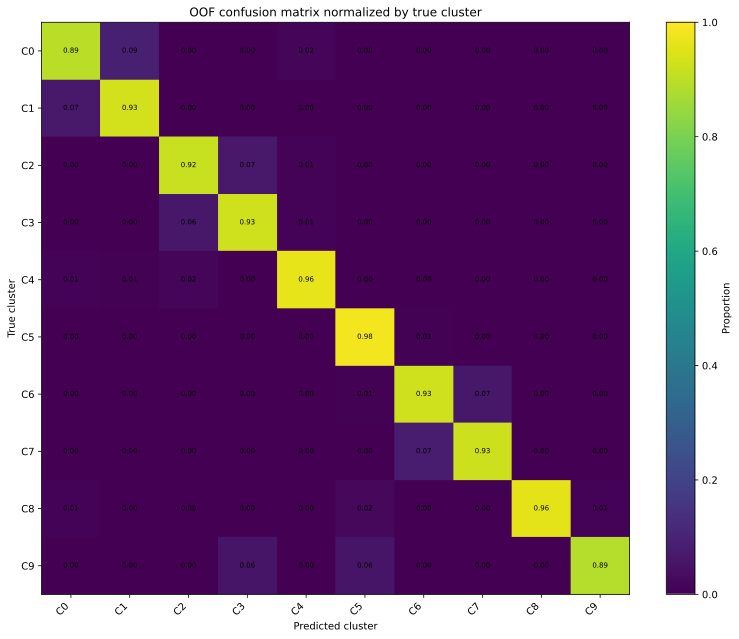

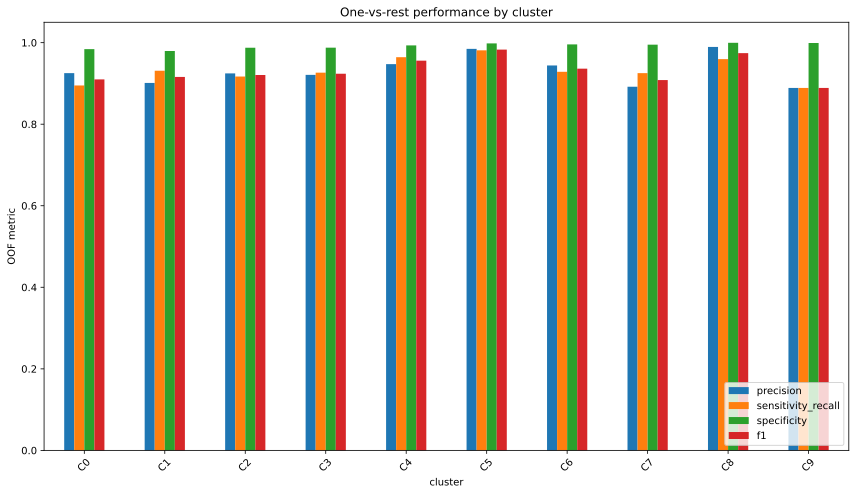

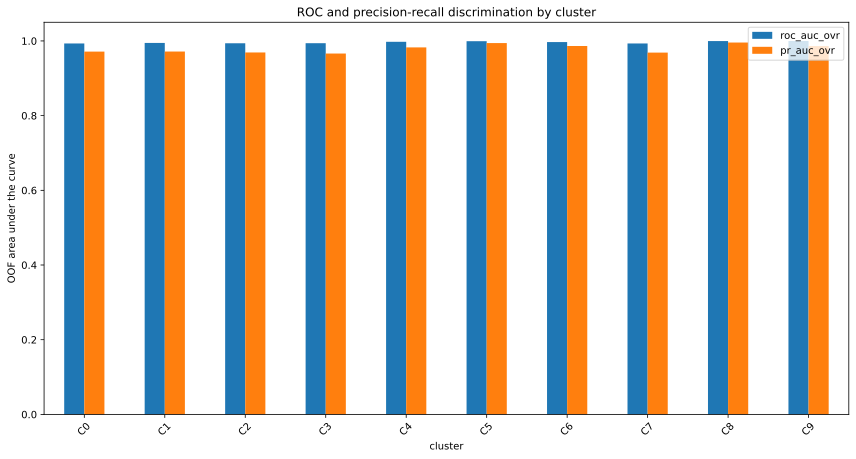

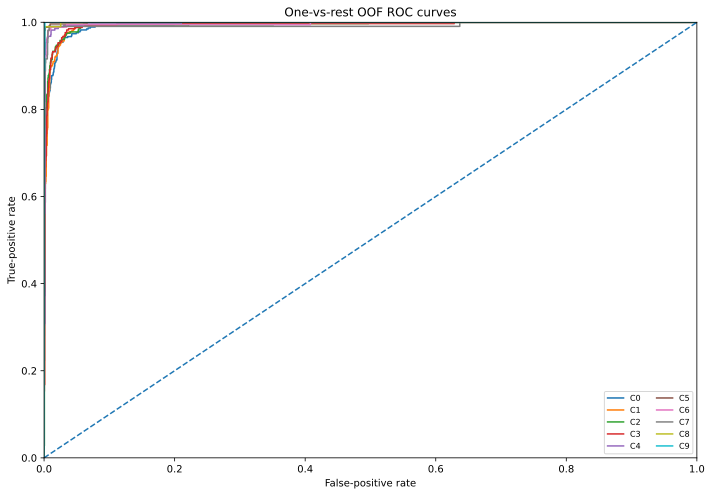

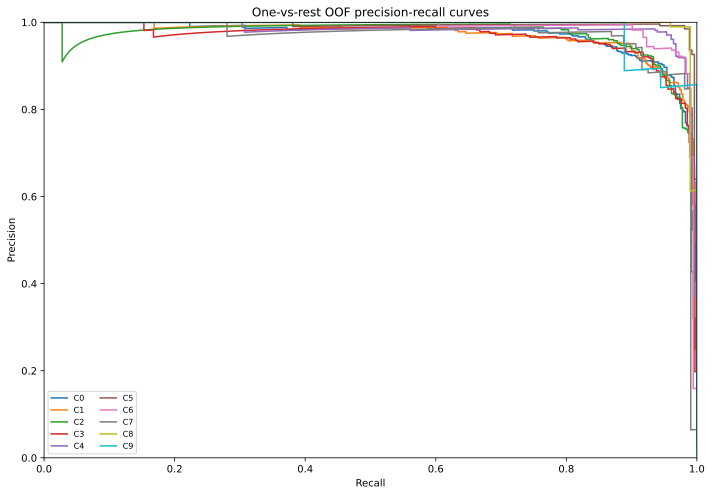

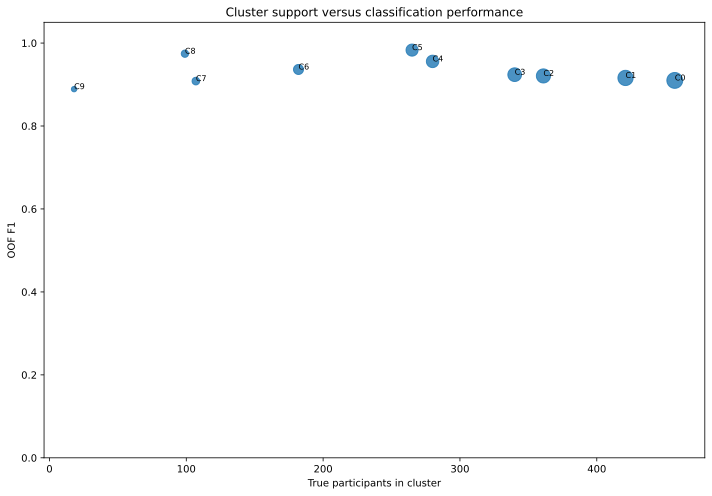

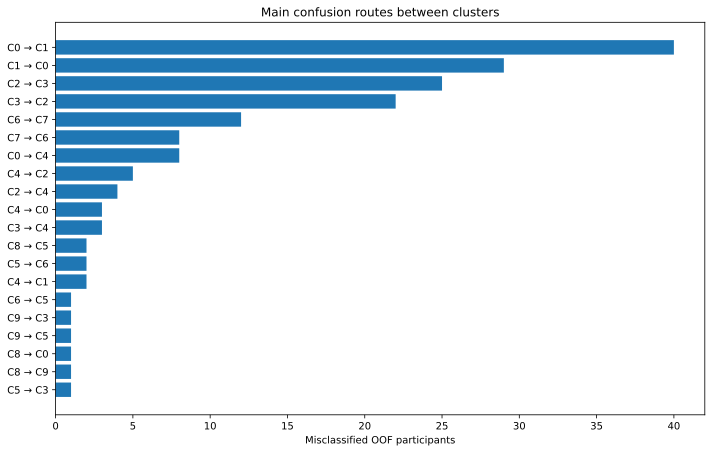

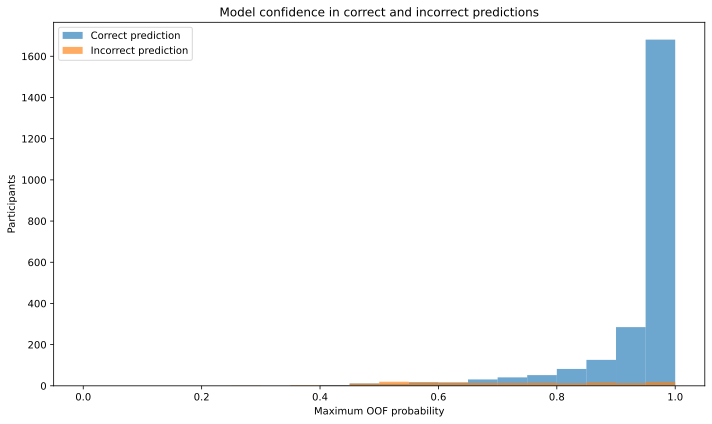

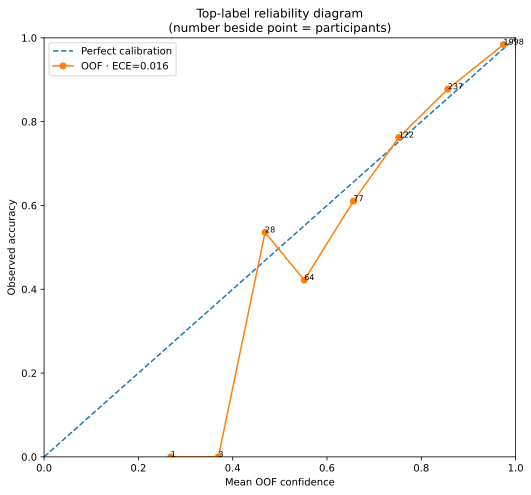

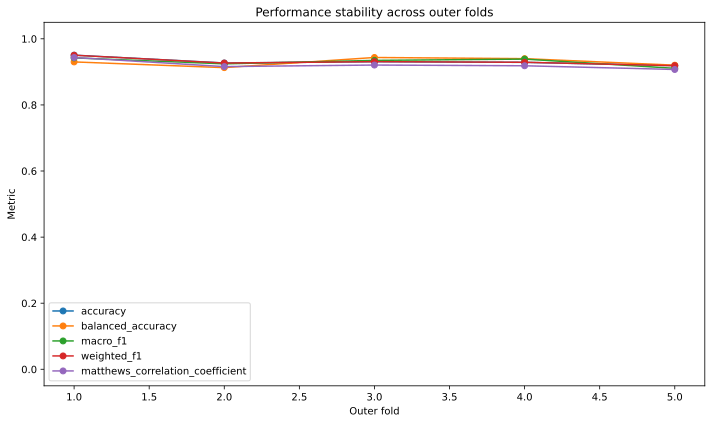

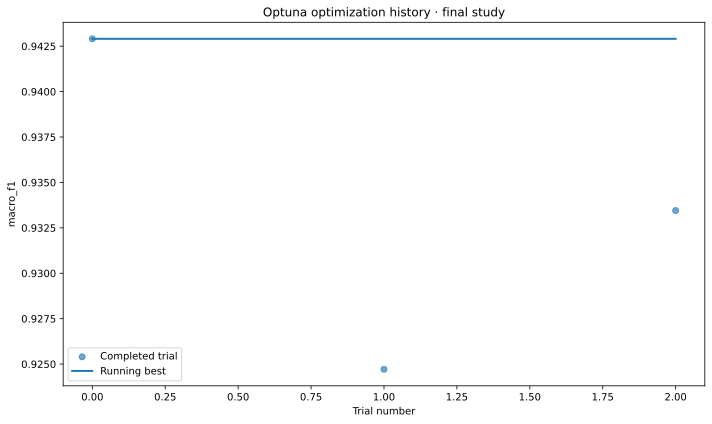

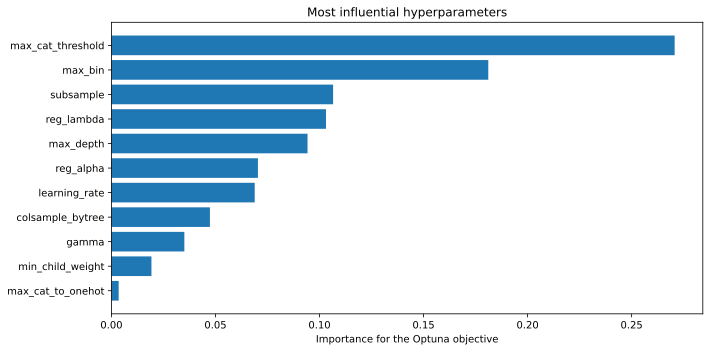

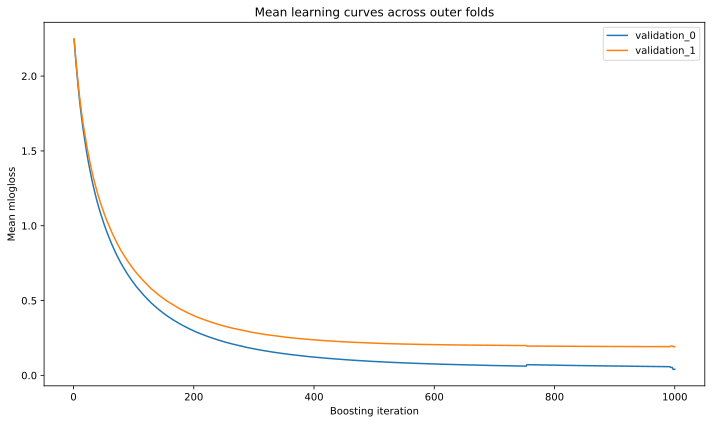

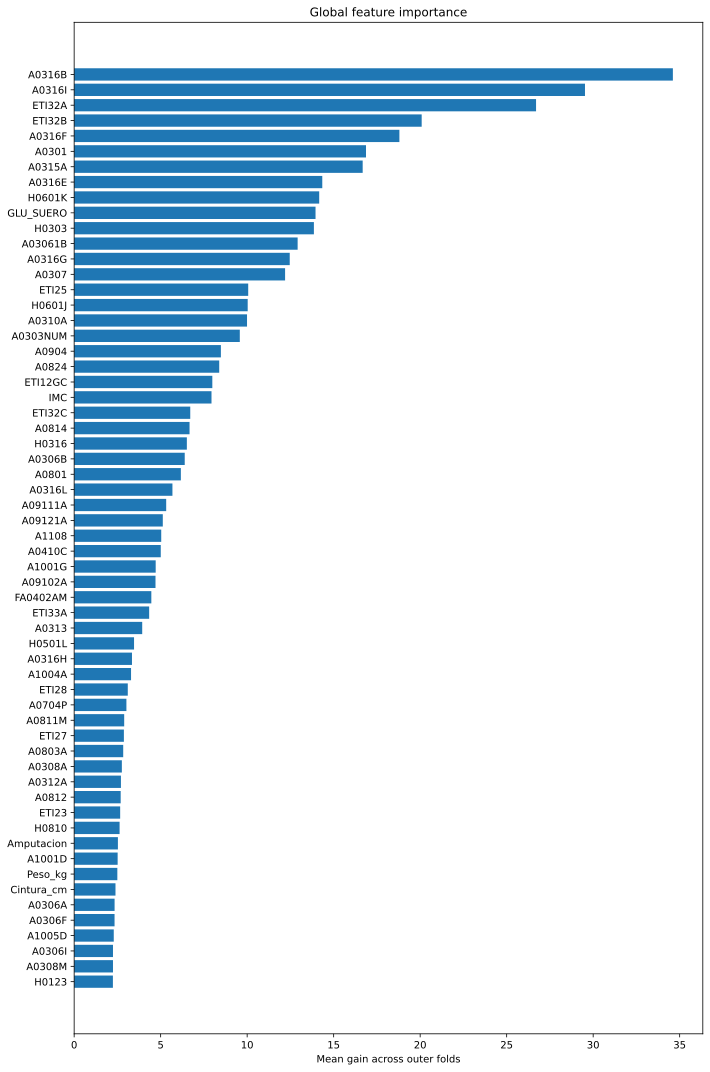

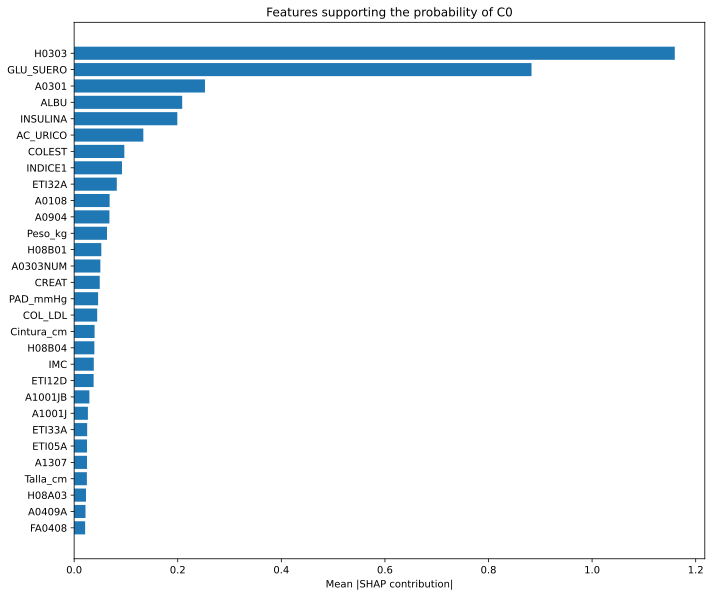

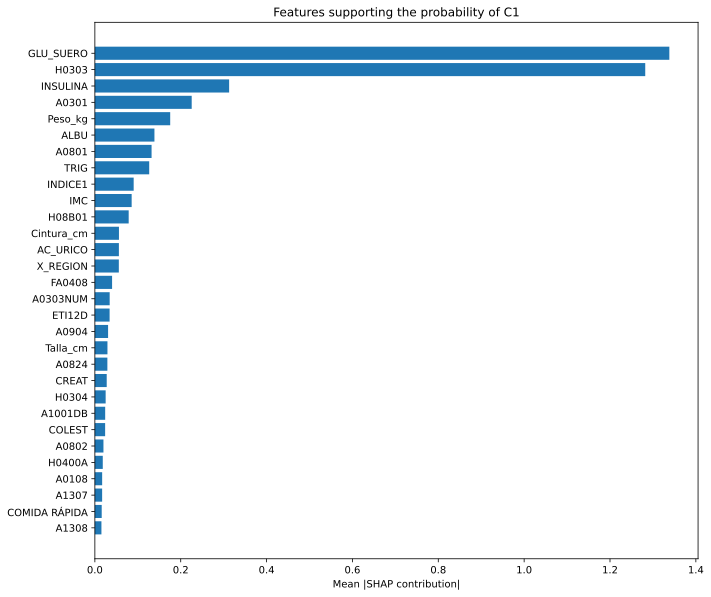

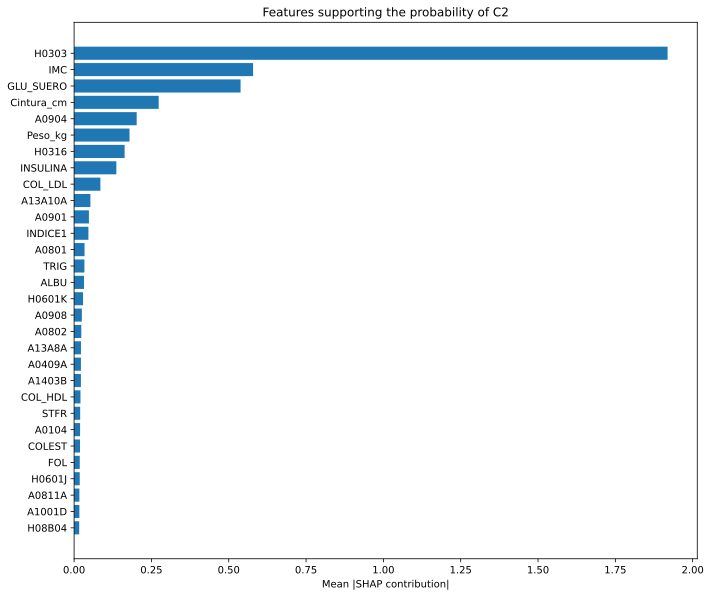

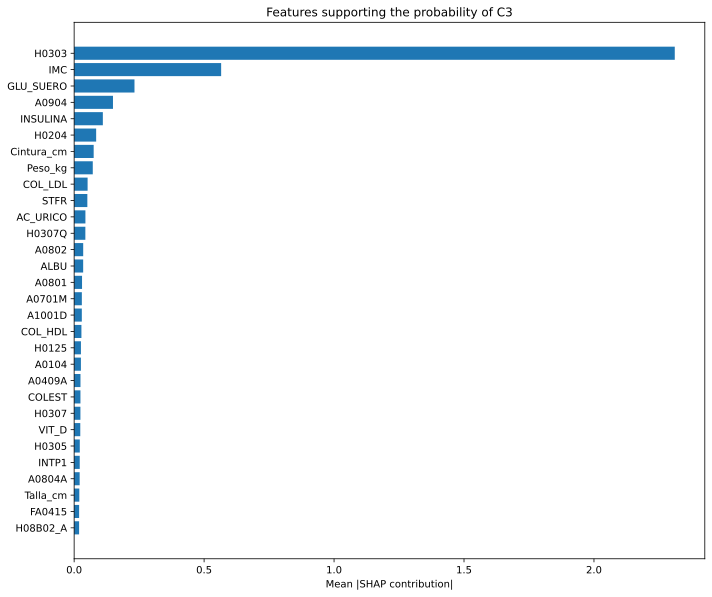

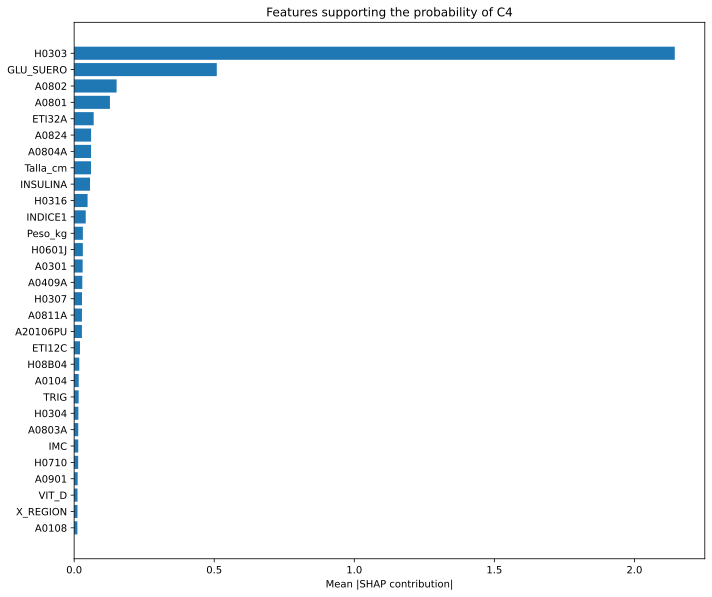

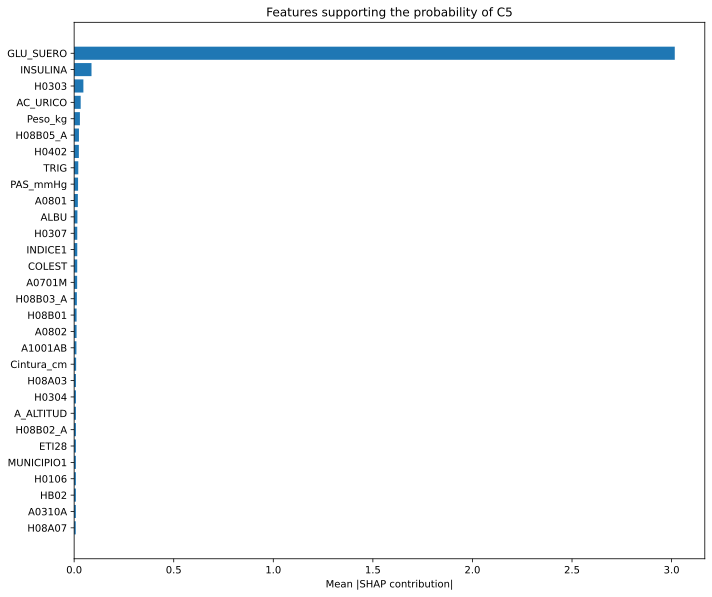

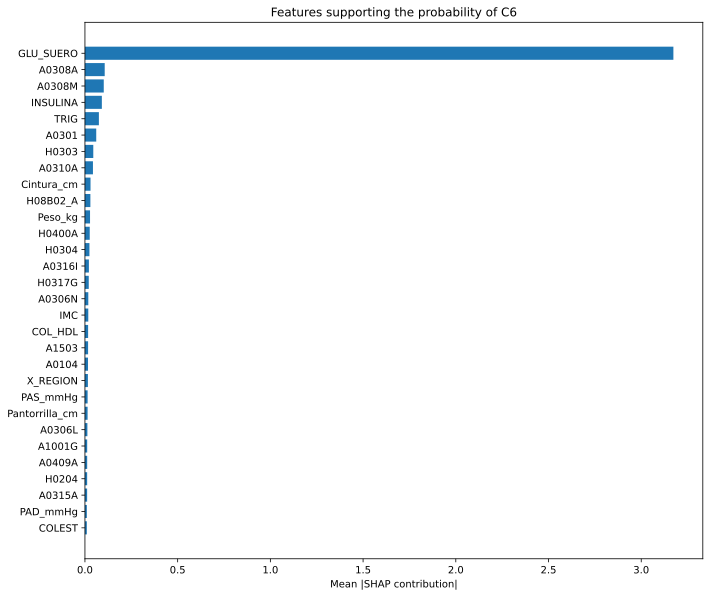

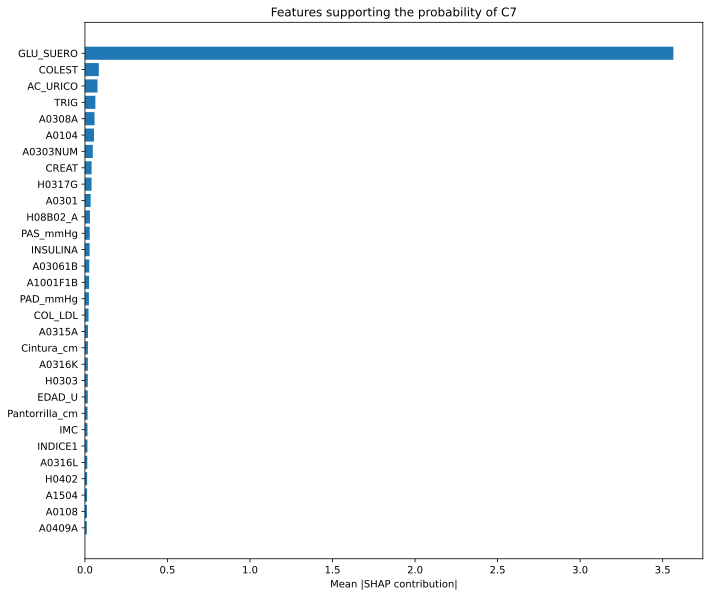

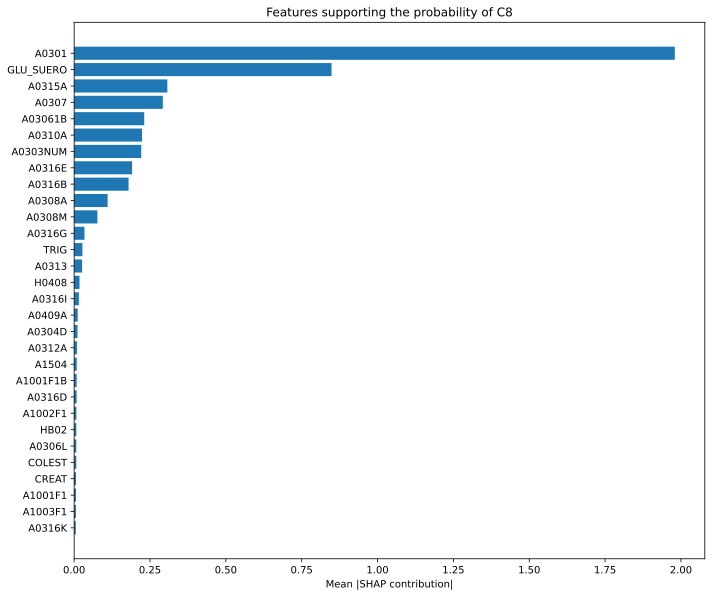

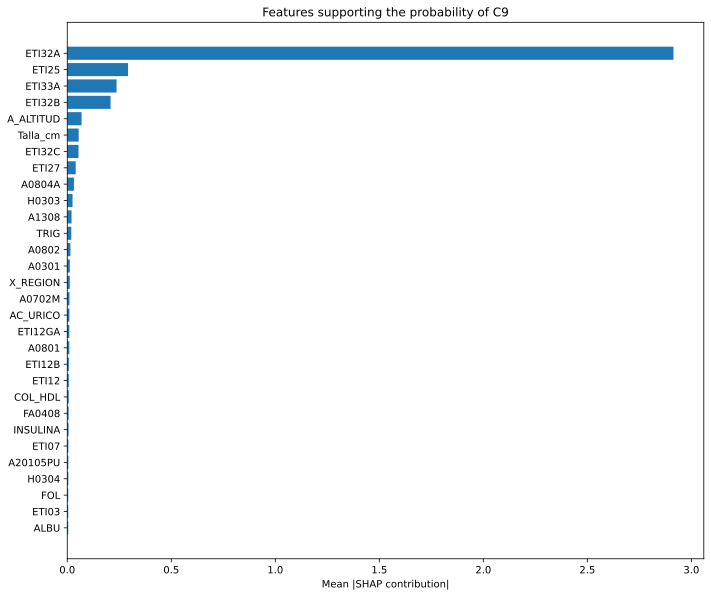


Diagnostic report:  80%|▊| 4/5 [00:12<00:03,  3.09s/stage, generate diagnostic 
Diagnostic report:  80%|▊| 4/5 [00:12<00:03,  3.09s/stage, write manifest and Z
Diagnostic report: 100%|█| 5/5 [00:13<00:00,  2.62s/stage, write manifest and Z
XGBoost workflow: 100%|██████████████| 4/4 [03:15<00:00, 48.81s/task, complete]


,participants,NB_filtered_variables,XGBoost_predictors,clusters,report
0,2530,551,546,10,/Users/cristianjuliocesarpadronmanrique/Deskto...


,OOF_value
accuracy,0.931225
balanced_accuracy,0.931716
macro_precision,0.931884
macro_recall,0.931716
macro_f1,0.931680
weighted_f1,0.931234
cohen_kappa,0.920912
matthews_correlation_coefficient,0.920953
multiclass_log_loss,0.195996
macro_roc_auc_ovr,0.996259


,cluster,n_true,prevalence,n_predicted,TP,FP,FN,TN,precision,sensitivity_recall,specificity,f1,support,roc_auc_ovr,pr_auc_ovr
0,C0,457,0.180632,442,409,33,48,2040,0.925339,0.894967,0.984081,0.909900,457,0.993287,0.971520
1,C1,421,0.166403,435,392,43,29,2066,0.901149,0.931116,0.979611,0.915888,421,0.994612,0.971577
2,C2,361,0.142688,358,331,27,30,2142,0.924581,0.916898,0.987552,0.920723,361,0.993754,0.969174
3,C3,340,0.134387,342,315,27,25,2163,0.921053,0.926471,0.987671,0.923754,340,0.993889,0.966310
4,C4,280,0.110672,285,270,15,10,2235,0.947368,0.964286,0.993333,0.955752,280,0.997748,0.982772
5,C5,265,0.104743,264,260,4,5,2261,0.984848,0.981132,0.998234,0.982987,265,0.999392,0.994328
6,C6,182,0.071937,179,169,10,13,2338,0.944134,0.928571,0.995741,0.936288,182,0.997044,0.986526
7,C7,107,0.042292,111,99,12,8,2411,0.891892,0.925234,0.995047,0.908257,107,0.993242,0.968762
8,C8,99,0.039130,96,95,1,4,2430,0.989583,0.959596,0.999589,0.974359,99,0.999730,0.995801
9,C9,18,0.007115,18,16,2,2,2510,0.888889,0.888889,0.999204,0.888889,18,0.999889,0.986216


In [10]:
if RUN_XGBOOST_CROSS_VALIDATION:
    from ensanut_hba1c.io import load_ensanut_inputs
    from ensanut_hba1c.modeling import prepare_model_matrix
    from ensanut_hba1c.workflows.cluster_dataset import (
        ClusterDatasetConfig,
        prepare_cluster_dataset,
    )
    from ensanut_hba1c.workflows.progress import TaskProgress
    from ensanut_hba1c.workflows.xgboost_engine import (
        XGBoostConfig,
        run_xgboost_pipeline,
    )
    from ensanut_hba1c.workflows.xgboost_reporting import (
        XGBoostReportConfig,
        export_xgboost_results,
    )

    XGB_TASK_PROGRESS = TaskProgress(
        tasks=(
            "Load ENSANUT inputs",
            "Prepare the NB-filtered model matrix",
            "Run nested CV, Optuna, and SHAP",
            "Export metrics and diagnostic figures",
        ),
        description="XGBoost workflow",
        enabled=XGB_SHOW_PROGRESS_BARS,
        leave=XGB_PROGRESS_LEAVE,
        position=0,
    )

    XGB_TASK_PROGRESS.set_stage("load ENSANUT inputs")
    ensanut_df, model_dictionary_df = load_ensanut_inputs(
        PATHS.input_dir,
        data_filename="ENSANUT_2024_mx.csv",
        dictionary_filename="ENSANUT_2024.csv",
    )
    XGB_TASK_PROGRESS.complete("inputs loaded")

    MODEL_EXCLUDE_COLUMNS = sorted(set(
        REDUNDANT_AGE_COLUMNS
        + TARGET_DERIVED_COLUMNS
        + DIRECT_OUTCOME_OR_LEAKAGE_COLUMNS
        + NOTEBOOK2_EXCLUDE_VARIABLES
        + ["_merge"]
    ))
    FORBIDDEN_PREDICTORS = sorted(set(
        NB_FRAMEWORK_EXCLUDE_VARIABLES
        + NOTEBOOK2_EXCLUDE_VARIABLES
        + list(ID_COLUMNS)
        + [CLUSTER_COLUMN, "HB1AC", "_merge"]
    ))

    XGB_TASK_PROGRESS.set_stage("prepare NB-filtered predictors")
    PREPARED_CLUSTER_DATASET = prepare_cluster_dataset(
        ensanut_df,
        cluster_df,
        prepare_model_matrix_fn=prepare_model_matrix,
        evidence=NB_EVIDENCE,
        config=ClusterDatasetConfig(
            target_column_for_cohort="HB1AC",
            weight_column=None,
            id_columns=tuple(ID_COLUMNS),
            cluster_column=CLUSTER_COLUMN,
            max_categorical_levels=100,
            max_nb_features=NB_MAX_PREDICTORS,
        ),
        model_exclude_columns=MODEL_EXCLUDE_COLUMNS,
        forbidden_predictors=FORBIDDEN_PREDICTORS,
    )

    assert set(PREPARED_CLUSTER_DATASET.X.columns).issubset(
        set(NB_FILTERED_VARIABLES)
    ), "XGBoost contains variables outside the NB-filtered evidence set."
    XGB_TASK_PROGRESS.complete("model matrix ready")

    XGB_OUTPUT_DIR = PATHS.notebook2_results / "xgboost_cluster_classification_cv"
    XGB_TASK_PROGRESS.set_stage("nested CV, Optuna, and SHAP")
    XGB_RESULT = run_xgboost_pipeline(
        X=PREPARED_CLUSTER_DATASET.X,
        y=PREPARED_CLUSTER_DATASET.y,
        sample_weights=PREPARED_CLUSTER_DATASET.sample_weights,
        output_dir=XGB_OUTPUT_DIR,
        config=XGBoostConfig(
            random_state=XGB_RANDOM_STATE,
            outer_cv_splits=XGB_CV_N_SPLITS,
            inner_cv_splits=OPTUNA_INNER_CV_SPLITS,
            run_optuna=RUN_OPTUNA_HYPERPARAMETER_SEARCH,
            trials_per_outer_fold=OPTUNA_TRIALS_PER_OUTER_FOLD,
            final_trials=OPTUNA_FINAL_N_TRIALS,
            optuna_timeout_seconds=OPTUNA_TIMEOUT_SECONDS,
            optuna_study_basename=OPTUNA_STUDY_BASENAME,
            reuse_existing_studies=OPTUNA_REUSE_EXISTING_STUDIES,
            optuna_startup_trials=OPTUNA_N_STARTUP_TRIALS,
            optuna_pruner_startup_trials=OPTUNA_PRUNER_STARTUP_TRIALS,
            optuna_pruner_warmup_steps=OPTUNA_PRUNER_WARMUP_STEPS,
            objective_metric=OPTUNA_OBJECTIVE_METRIC,
            optuna_n_jobs=OPTUNA_N_JOBS,
            max_estimators=XGB_MAX_ESTIMATORS,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            tree_method=XGB_TREE_METHOD,
            n_jobs=XGB_N_JOBS,
            use_balanced_class_weights=XGB_USE_BALANCED_CLASS_WEIGHTS,
            shap_max_rows_per_fold=XGB_SHAP_MAX_ROWS_PER_FOLD,
            learning_rate_min=OPTUNA_LEARNING_RATE_MIN,
            learning_rate_max=OPTUNA_LEARNING_RATE_MAX,
            max_depth_min=OPTUNA_MAX_DEPTH_MIN,
            max_depth_max=OPTUNA_MAX_DEPTH_MAX,
            min_child_weight_min=OPTUNA_MIN_CHILD_WEIGHT_MIN,
            min_child_weight_max=OPTUNA_MIN_CHILD_WEIGHT_MAX,
            subsample_min=OPTUNA_SUBSAMPLE_MIN,
            subsample_max=OPTUNA_SUBSAMPLE_MAX,
            colsample_bytree_min=OPTUNA_COLSAMPLE_BYTREE_MIN,
            colsample_bytree_max=OPTUNA_COLSAMPLE_BYTREE_MAX,
            gamma_min=OPTUNA_GAMMA_MIN,
            gamma_max=OPTUNA_GAMMA_MAX,
            reg_alpha_min=OPTUNA_REG_ALPHA_MIN,
            reg_alpha_max=OPTUNA_REG_ALPHA_MAX,
            reg_lambda_min=OPTUNA_REG_LAMBDA_MIN,
            reg_lambda_max=OPTUNA_REG_LAMBDA_MAX,
            max_bin_options=tuple(OPTUNA_MAX_BIN_OPTIONS),
            max_cat_to_onehot_options=tuple(OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS),
            max_cat_threshold_options=tuple(OPTUNA_MAX_CAT_THRESHOLD_OPTIONS),
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    XGB_TASK_PROGRESS.complete("nested CV complete")

    XGB_TASK_PROGRESS.set_stage("export diagnostic report")
    XGB_OUTPUTS = export_xgboost_results(
        XGB_RESULT,
        XGB_OUTPUT_DIR,
        participant_keys=PREPARED_CLUSTER_DATASET.participant_keys,
        feature_selection_audit=PREPARED_CLUSTER_DATASET.feature_selection.audit,
        model_audit=PREPARED_CLUSTER_DATASET.model_audit,
        config=XGBoostReportConfig(
            dpi=XGB_REPORT_DPI,
            top_global_features=XGB_TOP_FEATURES_GLOBAL,
            top_features_per_cluster=XGB_TOP_FEATURES_PER_CLUSTER,
            top_confusion_pairs=XGB_TOP_CONFUSION_PAIRS,
            top_optuna_parameters=XGB_TOP_OPTUNA_PARAMETERS,
            calibration_bins=XGB_CALIBRATION_BINS,
            save_individual_plots=XGB_SAVE_INDIVIDUAL_PLOTS,
            show_in_notebook=XGB_SHOW_ALL_DIAGNOSTIC_FIGURES,
            show_summary_page_in_notebook=False,
            verbose=False,
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    PREPARED_CLUSTER_DATASET.feature_selection.export(
        XGB_OUTPUT_DIR / "feature_selection"
    )
    XGB_TASK_PROGRESS.complete("reports exported")
    XGB_TASK_PROGRESS.close("complete")

    display(pd.DataFrame([{
        "participants": len(PREPARED_CLUSTER_DATASET.X),
        "NB_filtered_variables": len(NB_FILTERED_VARIABLES),
        "XGBoost_predictors": PREPARED_CLUSTER_DATASET.X.shape[1],
        "clusters": PREPARED_CLUSTER_DATASET.y.nunique(),
        "report": str(XGB_OUTPUTS["pdf"]),
    }]))
    display(XGB_RESULT.global_metrics.T.rename(columns={0: "OOF_value"}))
    display(XGB_RESULT.metrics_by_cluster)
else:
    print("XGBoost cross-validation is disabled.")


## 10. XGBoost prediction after merging C5–C8

C5, C6, C7, and C8 are relabeled as one class (`C5-C8`). The classifier is then trained again from scratch with the same predictors, nested cross-validation, Optuna search, SHAP diagnostics, and reporting settings used for the original ten-cluster target. Outputs are written to a separate folder.


,cluster,participants
0,C5-C8,653
1,C0,457
2,C1,421
3,C2,361
4,C3,340
5,C4,280
6,C9,18


Merged C5-C8 XGBoost workflow:  33%|▎| 1/3 [00:00<00:00, 4429.04task/s, nested 
XGBoost pipeline:   0%|      | 0/8 [00:00<?, ?stage/s, outer fold 1/5 · Optuna]

Optuna · outer fold 1:   0%|                          | 0/8 [00:00<?, ?trial/s]

Optuna · outer fold 1:   0%| | 0/8 [00:00<?, ?trial/s, trial=1, inner fold=1/2]

Optuna · outer fold 1:   0%| | 0/8 [00:12<?, ?trial/s, trial=1, inner fold=2/2]

Optuna · outer fold 1:  12%|▏| 1/8 [00:24<02:50, 24.33s/trial, trial=1, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:24<02:50, 24.33s/trial, trial=1, score=0

Optuna · outer fold 1:  12%|▏| 1/8 [00:24<02:50, 24.33s/trial, trial=2, inner f

Optuna · outer fold 1:  12%|▏| 1/8 [00:26<02:50, 24.33s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:29<01:17, 12.97s/trial, trial=2, inner f

Optuna · outer fold 1:  25%|▎| 2/8 [00:29<01:17, 12.97s/trial, trial=2, score=0

Optuna · outer fold 1:  25%|▎| 2/8 [00:29<01:17, 12.97s/trial, trial=3, inner f

Optuna · outer fold 1:  25%|▎

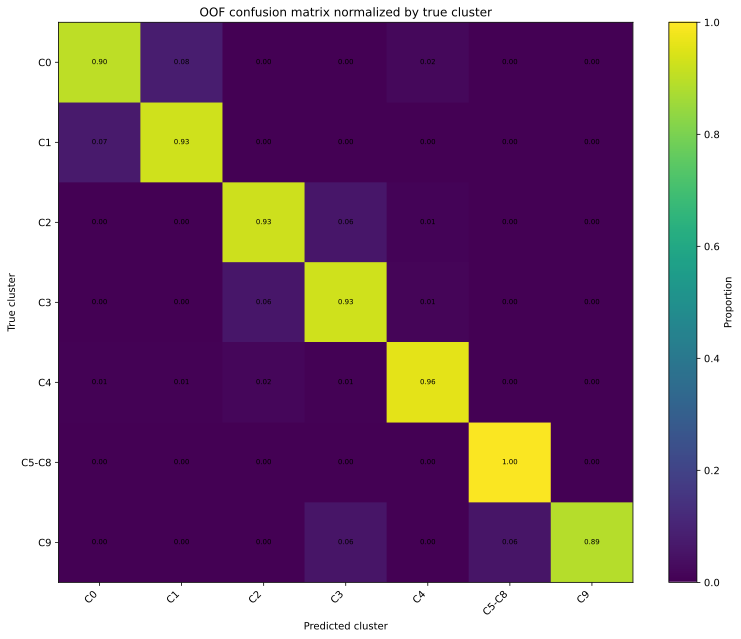

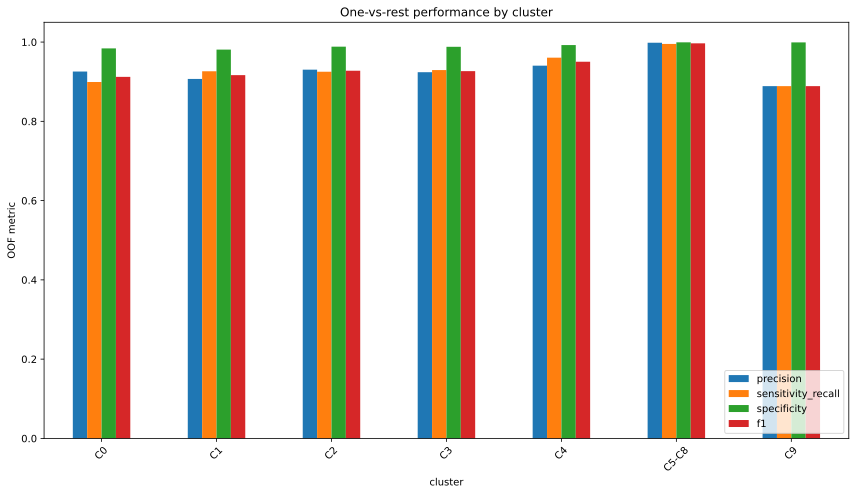

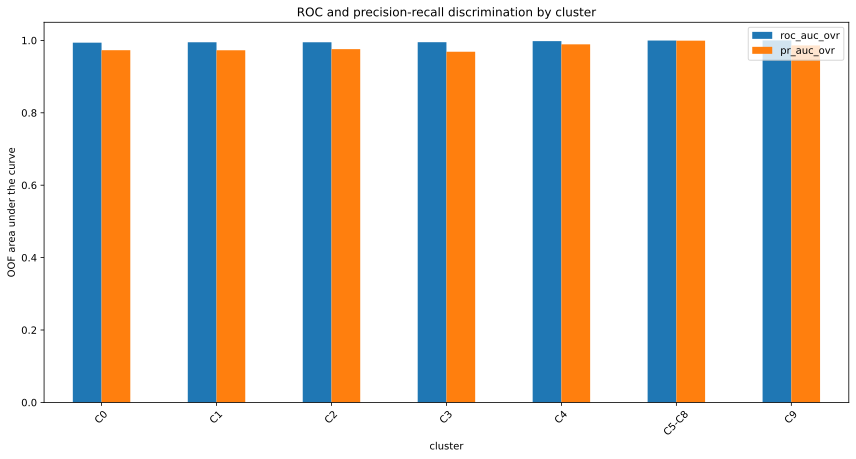

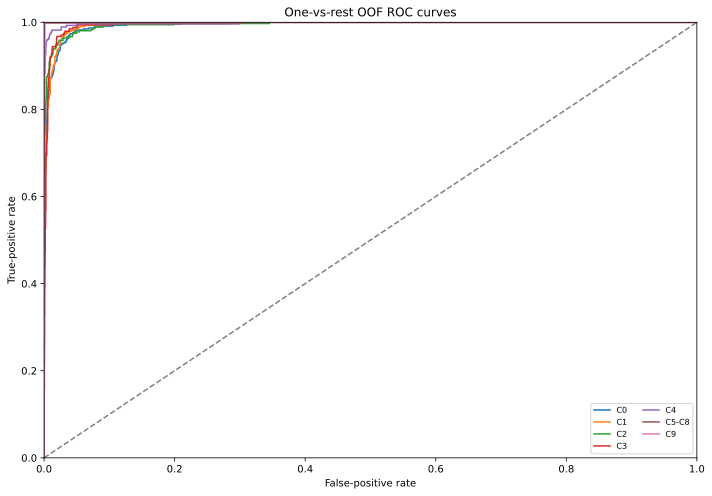

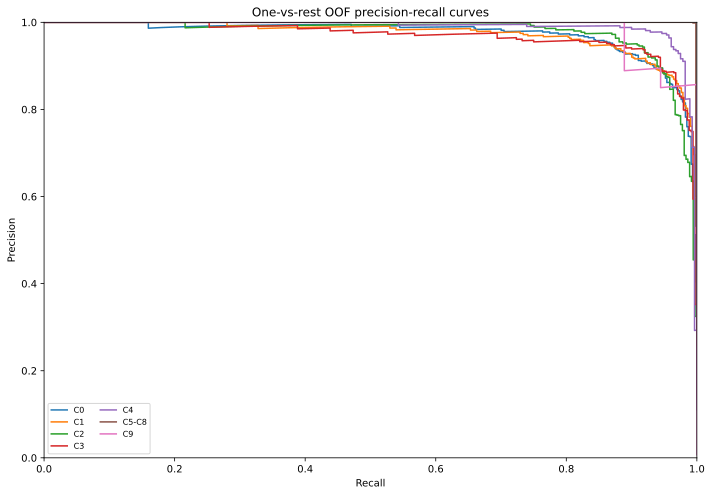

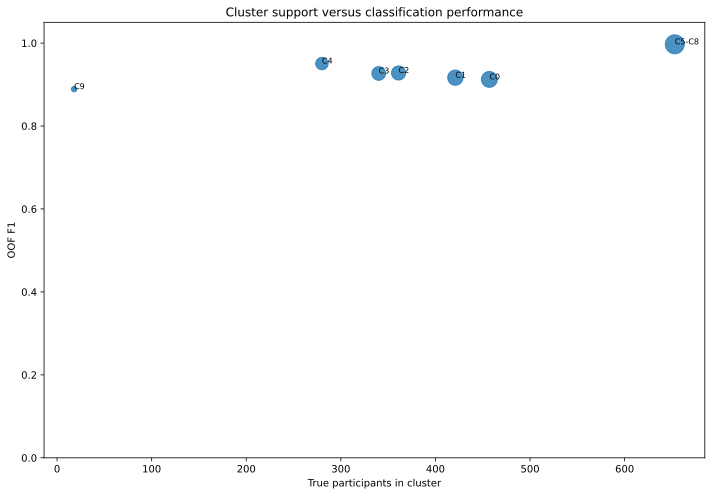

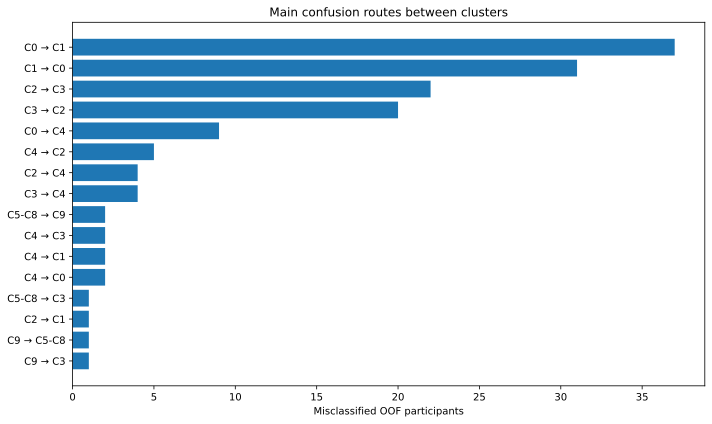

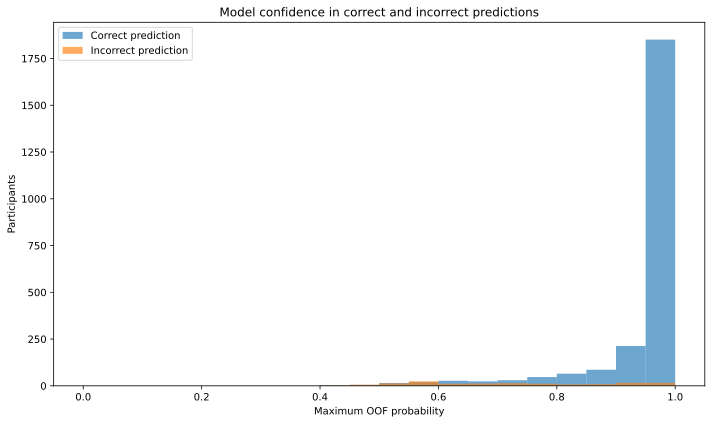

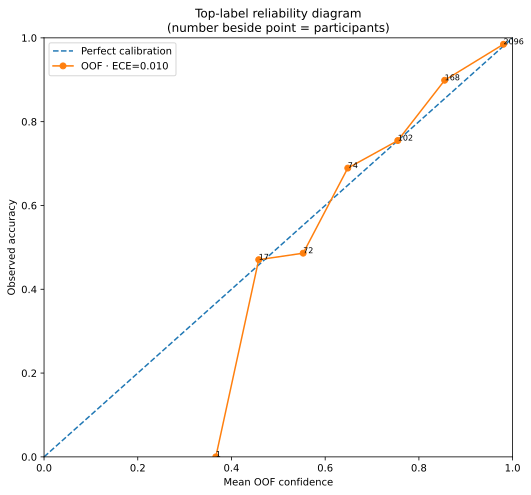

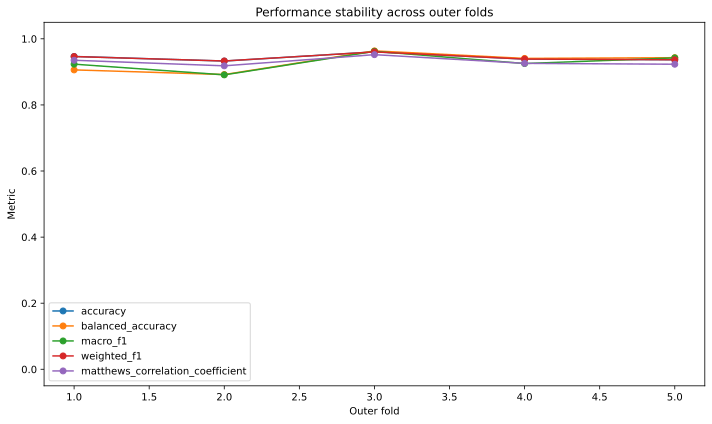

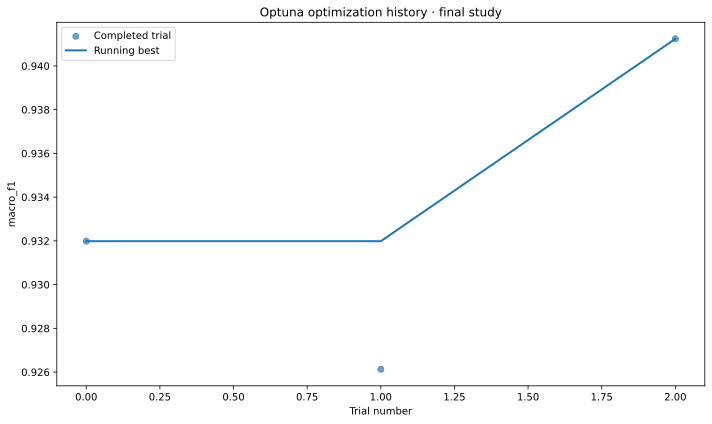

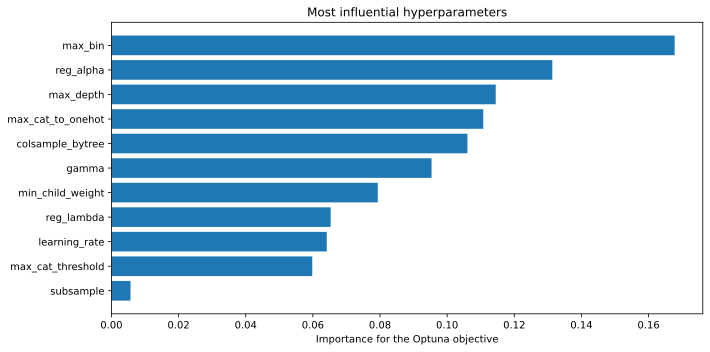

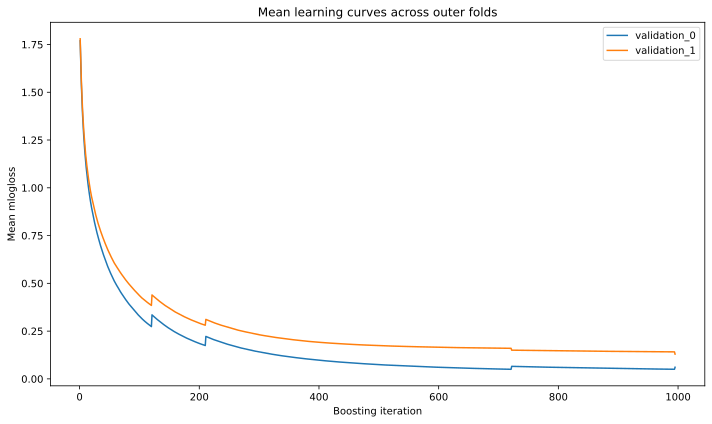

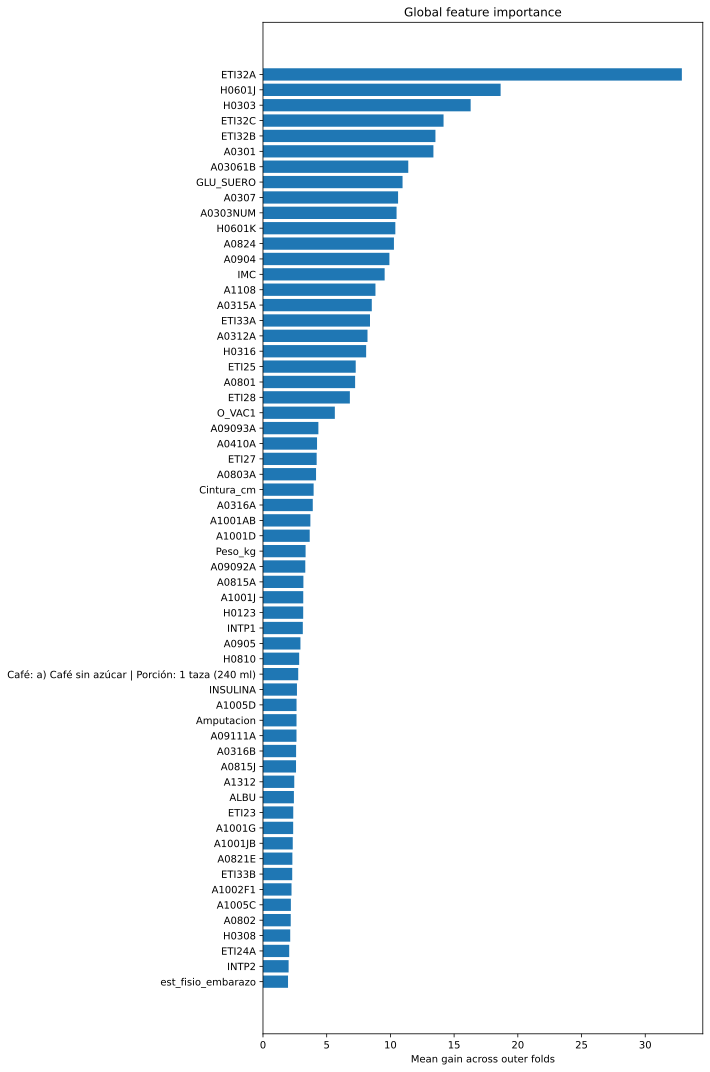

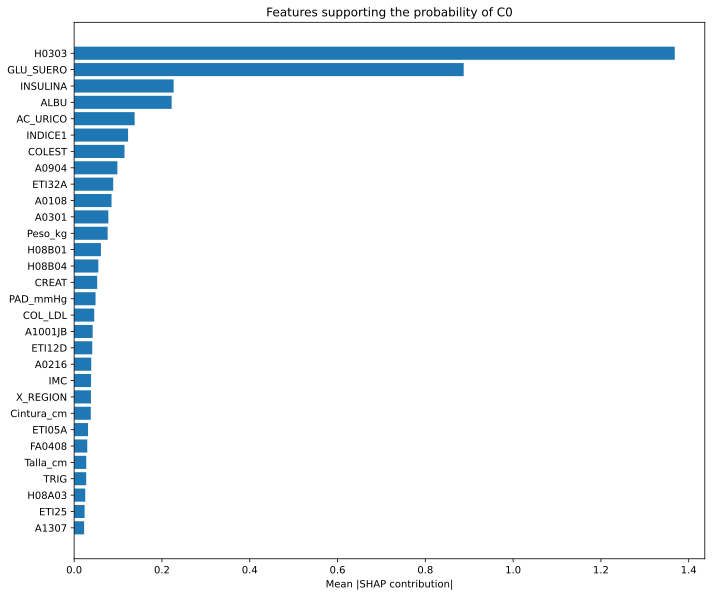

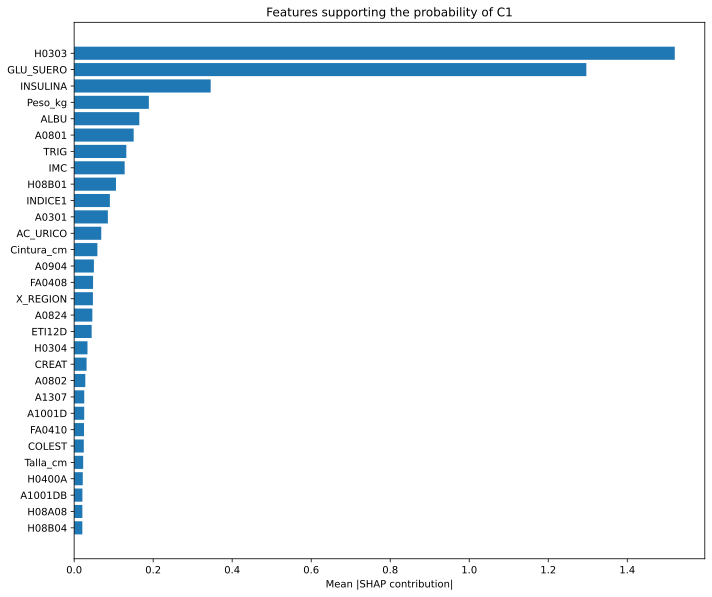

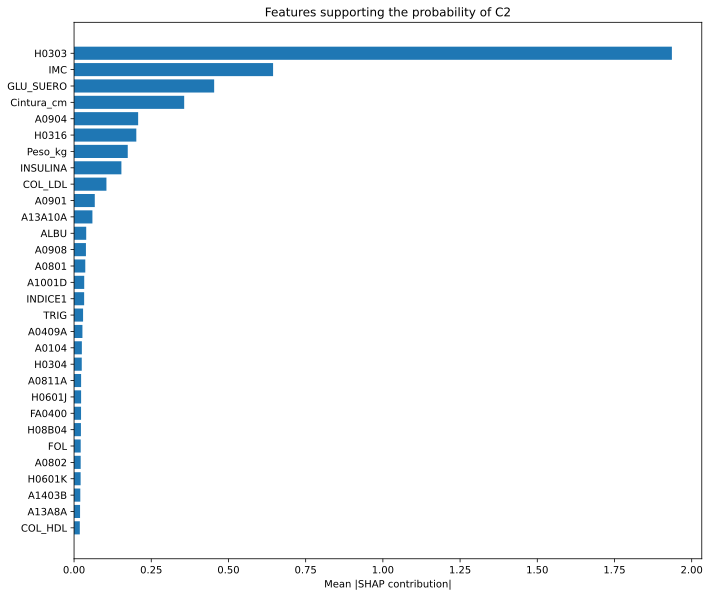

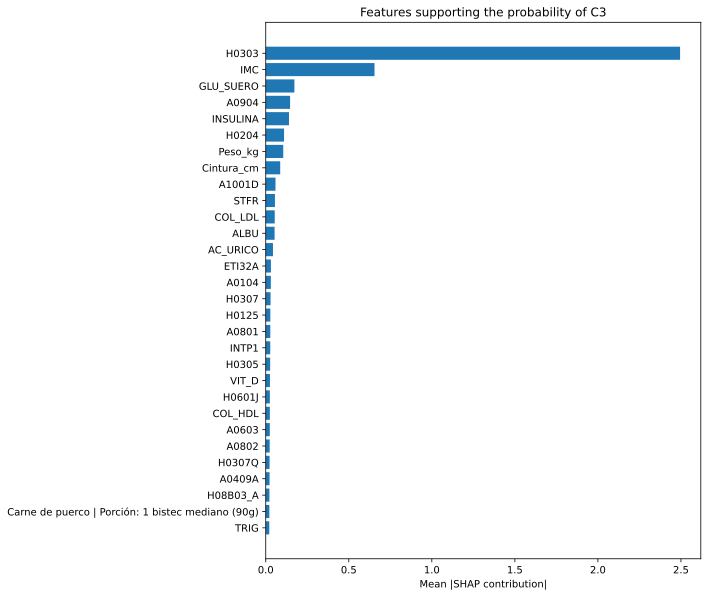

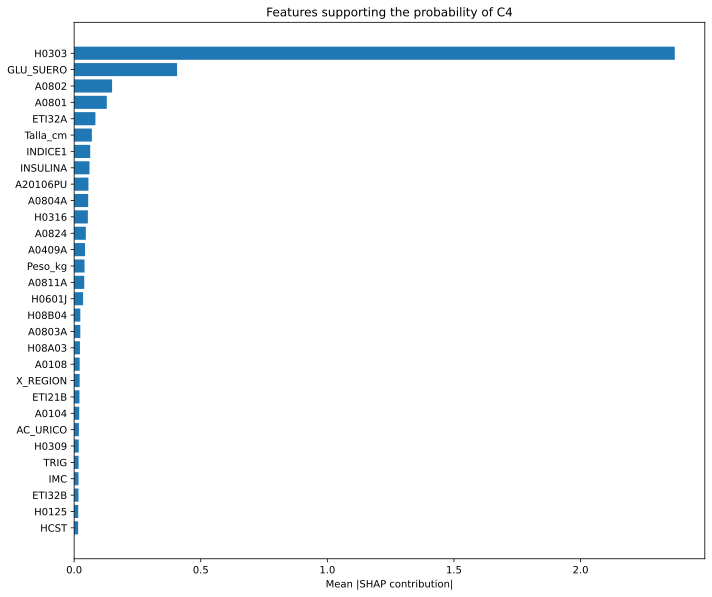

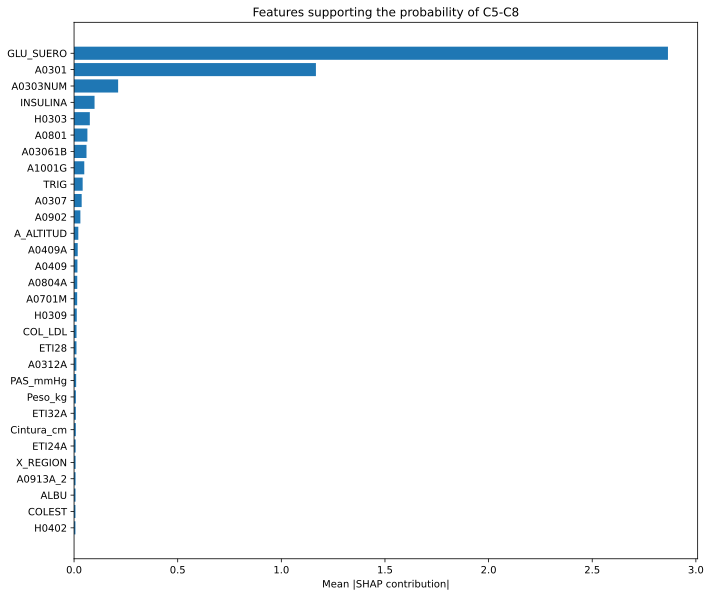

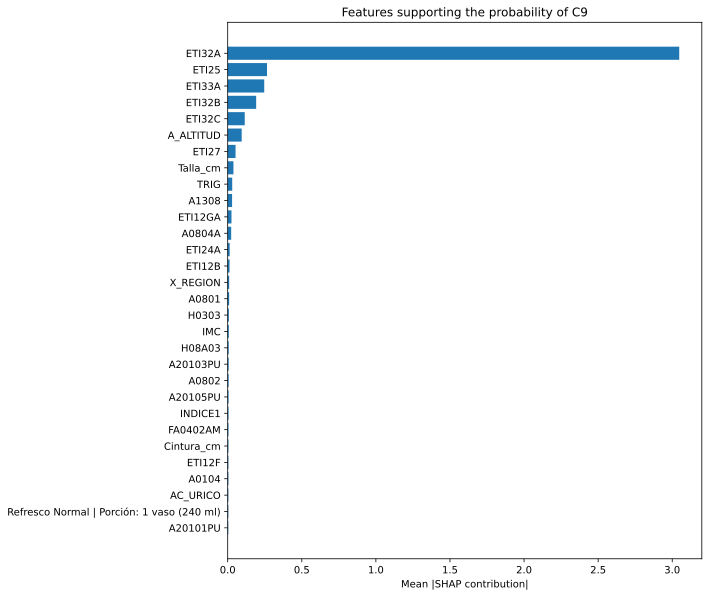


Diagnostic report:  80%|▊| 4/5 [00:08<00:02,  2.18s/stage, generate diagnostic 
Diagnostic report:  80%|▊| 4/5 [00:08<00:02,  2.18s/stage, write manifest and Z
Diagnostic report: 100%|█| 5/5 [00:08<00:00,  1.70s/stage, write manifest and Z
Diagnostic report: 100%|████████████| 5/5 [00:08<00:00,  1.76s/stage, complete]
Merged C5-C8 XGBoost workflow: 100%|█| 3/3 [14:04<00:00, 281.47s/task, complete


,participants,NB_filtered_variables,XGBoost_predictors,original_clusters,merged_classes,merged_label,report
0,2530,551,546,10,7,C5-C8,/Users/cristianjuliocesarpadronmanrique/Deskto...


,OOF_value
accuracy,0.943083
balanced_accuracy,0.932191
macro_precision,0.930700
macro_recall,0.932191
macro_f1,0.931386
weighted_f1,0.943064
cohen_kappa,0.930811
matthews_correlation_coefficient,0.930837
multiclass_log_loss,0.160316
macro_roc_auc_ovr,0.996521


,cluster,n_true,prevalence,n_predicted,TP,FP,FN,TN,precision,sensitivity_recall,specificity,f1,support,roc_auc_ovr,pr_auc_ovr
0,C0,457,0.180632,444,411,33,46,2040,0.925676,0.899344,0.984081,0.912320,457,0.993650,0.972862
1,C1,421,0.166403,430,390,40,31,2069,0.906977,0.926366,0.981034,0.916569,421,0.994810,0.972753
2,C2,361,0.142688,359,334,25,27,2144,0.930362,0.925208,0.988474,0.927778,361,0.994870,0.975838
3,C3,340,0.134387,342,316,26,24,2164,0.923977,0.929412,0.988128,0.926686,340,0.995051,0.968567
4,C4,280,0.110672,286,269,17,11,2233,0.940559,0.960714,0.992444,0.950530,280,0.997851,0.989062
5,C5-C8,653,0.258103,651,650,1,3,1876,0.998464,0.995406,0.999467,0.996933,653,0.999529,0.999277
6,C9,18,0.007115,18,16,2,2,2510,0.888889,0.888889,0.999204,0.888889,18,0.999889,0.986216


In [11]:
if RUN_XGBOOST_CROSS_VALIDATION and RUN_MERGED_CLUSTER_CROSS_VALIDATION:
    if "PREPARED_CLUSTER_DATASET" not in globals():
        raise RuntimeError(
            "Run the original 10-cluster XGBoost cell before this cell."
        )

    original_cluster_labels = PREPARED_CLUSTER_DATASET.y.astype(str)
    observed_cluster_labels = set(original_cluster_labels.unique())
    missing_merged_clusters = (
        set(MERGED_CLUSTER_MEMBERS) - observed_cluster_labels
    )
    if missing_merged_clusters:
        raise ValueError(
            "Cannot merge absent clusters: "
            + ", ".join(sorted(missing_merged_clusters))
        )

    MERGED_CLUSTER_Y = original_cluster_labels.replace(
        {cluster: MERGED_CLUSTER_LABEL for cluster in MERGED_CLUSTER_MEMBERS}
    )
    expected_merged_class_count = (
        original_cluster_labels.nunique() - len(MERGED_CLUSTER_MEMBERS) + 1
    )
    if MERGED_CLUSTER_Y.nunique() != expected_merged_class_count:
        raise AssertionError(
            "Unexpected number of classes after merging C5-C8."
        )

    merged_class_counts = (
        MERGED_CLUSTER_Y.value_counts()
        .rename_axis("cluster")
        .reset_index(name="participants")
    )
    display(merged_class_counts)

    MERGED_XGB_OUTPUT_DIR = (
        PATHS.notebook2_results
        / "xgboost_cluster_classification_cv_C5_C8_merged"
    )

    MERGED_XGB_TASK_PROGRESS = TaskProgress(
        tasks=(
            "Validate C5-C8 merged labels",
            "Run nested CV, Optuna, and SHAP",
            "Export metrics and diagnostic figures",
        ),
        description="Merged C5-C8 XGBoost workflow",
        enabled=XGB_SHOW_PROGRESS_BARS,
        leave=XGB_PROGRESS_LEAVE,
        position=0,
    )
    MERGED_XGB_TASK_PROGRESS.complete("merged labels ready")

    MERGED_XGB_TASK_PROGRESS.set_stage(
        "nested CV, Optuna, and SHAP"
    )
    MERGED_XGB_RESULT = run_xgboost_pipeline(
        X=PREPARED_CLUSTER_DATASET.X,
        y=MERGED_CLUSTER_Y,
        sample_weights=PREPARED_CLUSTER_DATASET.sample_weights,
        output_dir=MERGED_XGB_OUTPUT_DIR,
        config=XGBoostConfig(
            random_state=XGB_RANDOM_STATE,
            outer_cv_splits=XGB_CV_N_SPLITS,
            inner_cv_splits=OPTUNA_INNER_CV_SPLITS,
            run_optuna=RUN_OPTUNA_HYPERPARAMETER_SEARCH,
            trials_per_outer_fold=OPTUNA_TRIALS_PER_OUTER_FOLD,
            final_trials=OPTUNA_FINAL_N_TRIALS,
            optuna_timeout_seconds=OPTUNA_TIMEOUT_SECONDS,
            optuna_study_basename=(
                f"{OPTUNA_STUDY_BASENAME}_C5_C8_merged"
            ),
            reuse_existing_studies=OPTUNA_REUSE_EXISTING_STUDIES,
            optuna_startup_trials=OPTUNA_N_STARTUP_TRIALS,
            optuna_pruner_startup_trials=OPTUNA_PRUNER_STARTUP_TRIALS,
            optuna_pruner_warmup_steps=OPTUNA_PRUNER_WARMUP_STEPS,
            objective_metric=OPTUNA_OBJECTIVE_METRIC,
            optuna_n_jobs=OPTUNA_N_JOBS,
            max_estimators=XGB_MAX_ESTIMATORS,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            tree_method=XGB_TREE_METHOD,
            n_jobs=XGB_N_JOBS,
            use_balanced_class_weights=XGB_USE_BALANCED_CLASS_WEIGHTS,
            shap_max_rows_per_fold=XGB_SHAP_MAX_ROWS_PER_FOLD,
            learning_rate_min=OPTUNA_LEARNING_RATE_MIN,
            learning_rate_max=OPTUNA_LEARNING_RATE_MAX,
            max_depth_min=OPTUNA_MAX_DEPTH_MIN,
            max_depth_max=OPTUNA_MAX_DEPTH_MAX,
            min_child_weight_min=OPTUNA_MIN_CHILD_WEIGHT_MIN,
            min_child_weight_max=OPTUNA_MIN_CHILD_WEIGHT_MAX,
            subsample_min=OPTUNA_SUBSAMPLE_MIN,
            subsample_max=OPTUNA_SUBSAMPLE_MAX,
            colsample_bytree_min=OPTUNA_COLSAMPLE_BYTREE_MIN,
            colsample_bytree_max=OPTUNA_COLSAMPLE_BYTREE_MAX,
            gamma_min=OPTUNA_GAMMA_MIN,
            gamma_max=OPTUNA_GAMMA_MAX,
            reg_alpha_min=OPTUNA_REG_ALPHA_MIN,
            reg_alpha_max=OPTUNA_REG_ALPHA_MAX,
            reg_lambda_min=OPTUNA_REG_LAMBDA_MIN,
            reg_lambda_max=OPTUNA_REG_LAMBDA_MAX,
            max_bin_options=tuple(OPTUNA_MAX_BIN_OPTIONS),
            max_cat_to_onehot_options=tuple(
                OPTUNA_MAX_CAT_TO_ONEHOT_OPTIONS
            ),
            max_cat_threshold_options=tuple(
                OPTUNA_MAX_CAT_THRESHOLD_OPTIONS
            ),
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    MERGED_XGB_TASK_PROGRESS.complete("nested CV complete")

    MERGED_XGB_TASK_PROGRESS.set_stage("export diagnostic report")
    MERGED_XGB_OUTPUTS = export_xgboost_results(
        MERGED_XGB_RESULT,
        MERGED_XGB_OUTPUT_DIR,
        participant_keys=PREPARED_CLUSTER_DATASET.participant_keys,
        feature_selection_audit=(
            PREPARED_CLUSTER_DATASET.feature_selection.audit
        ),
        model_audit=PREPARED_CLUSTER_DATASET.model_audit,
        config=XGBoostReportConfig(
            dpi=XGB_REPORT_DPI,
            top_global_features=XGB_TOP_FEATURES_GLOBAL,
            top_features_per_cluster=XGB_TOP_FEATURES_PER_CLUSTER,
            top_confusion_pairs=XGB_TOP_CONFUSION_PAIRS,
            top_optuna_parameters=XGB_TOP_OPTUNA_PARAMETERS,
            calibration_bins=XGB_CALIBRATION_BINS,
            save_individual_plots=XGB_SAVE_INDIVIDUAL_PLOTS,
            show_in_notebook=XGB_SHOW_ALL_DIAGNOSTIC_FIGURES,
            show_summary_page_in_notebook=False,
            verbose=False,
            show_progress_bars=XGB_SHOW_PROGRESS_BARS,
            progress_leave=XGB_PROGRESS_LEAVE,
        ),
    )
    PREPARED_CLUSTER_DATASET.feature_selection.export(
        MERGED_XGB_OUTPUT_DIR / "feature_selection"
    )
    MERGED_XGB_TASK_PROGRESS.complete("reports exported")
    MERGED_XGB_TASK_PROGRESS.close("complete")

    display(pd.DataFrame([{
        "participants": len(PREPARED_CLUSTER_DATASET.X),
        "NB_filtered_variables": len(NB_FILTERED_VARIABLES),
        "XGBoost_predictors": PREPARED_CLUSTER_DATASET.X.shape[1],
        "original_clusters": original_cluster_labels.nunique(),
        "merged_classes": MERGED_CLUSTER_Y.nunique(),
        "merged_label": MERGED_CLUSTER_LABEL,
        "report": str(MERGED_XGB_OUTPUTS["pdf"]),
    }]))
    display(
        MERGED_XGB_RESULT.global_metrics.T.rename(
            columns={0: "OOF_value"}
        )
    )
    display(MERGED_XGB_RESULT.metrics_by_cluster)
else:
    print("Merged C5-C8 XGBoost cross-validation is disabled.")


## Pre-rendered figure gallery

**45 figures** embedded below as PNG/JPEG outputs. No execution is required.

### Figure 1
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

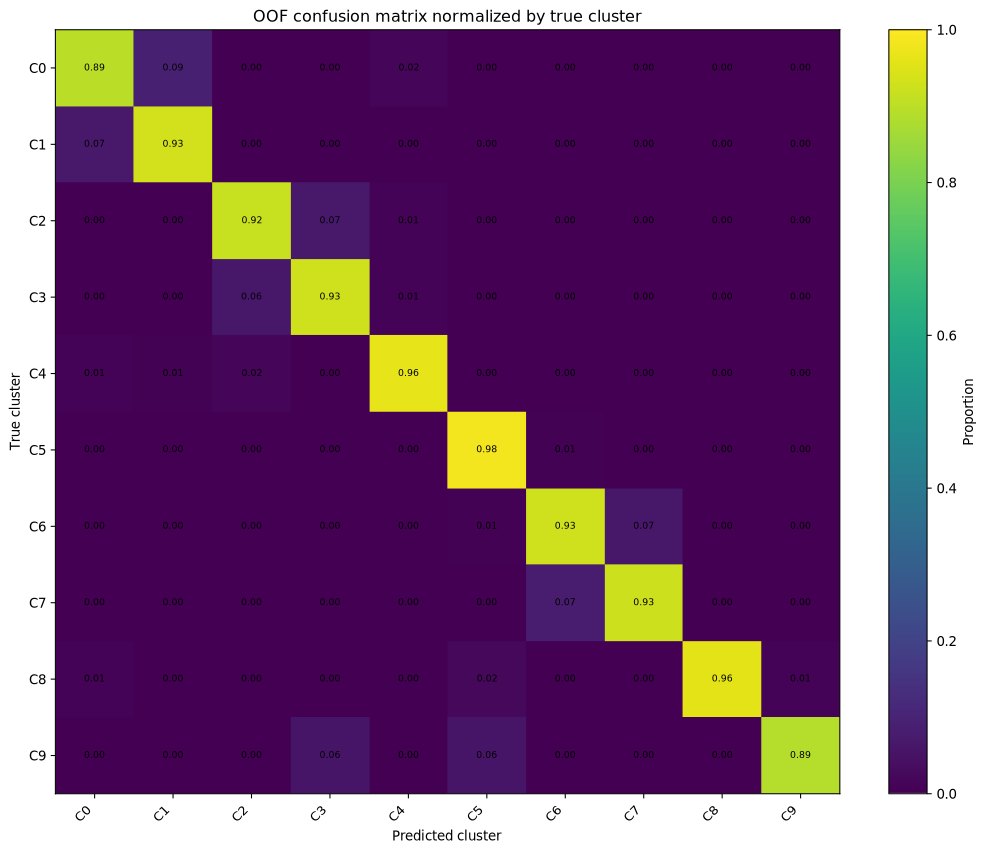

### Figure 2
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

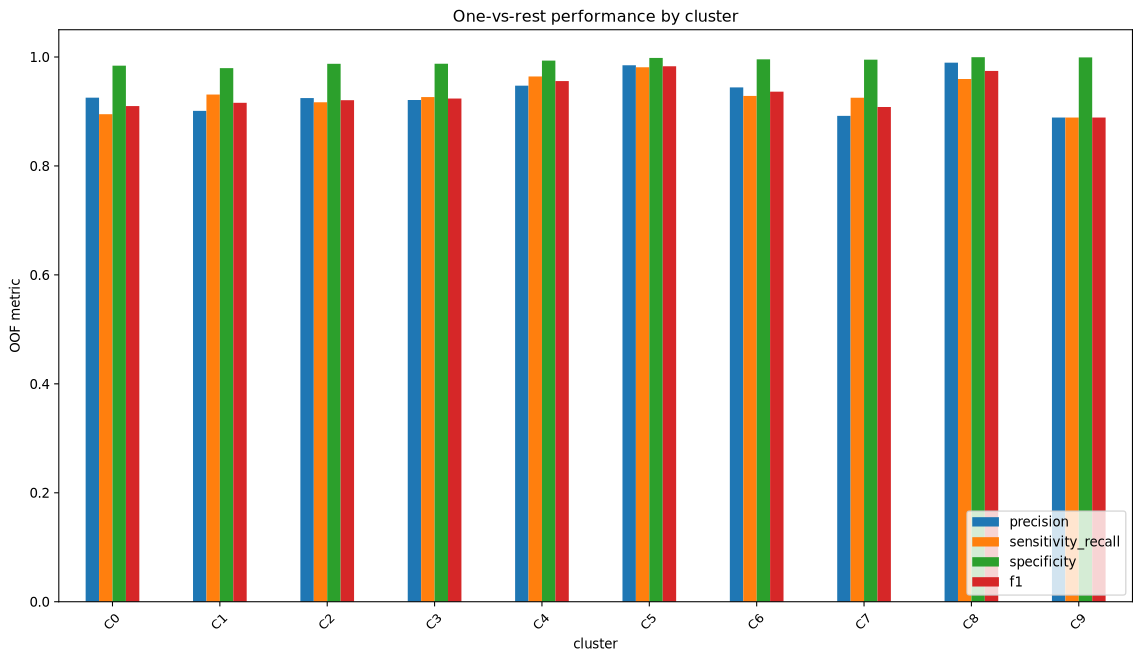

### Figure 3
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

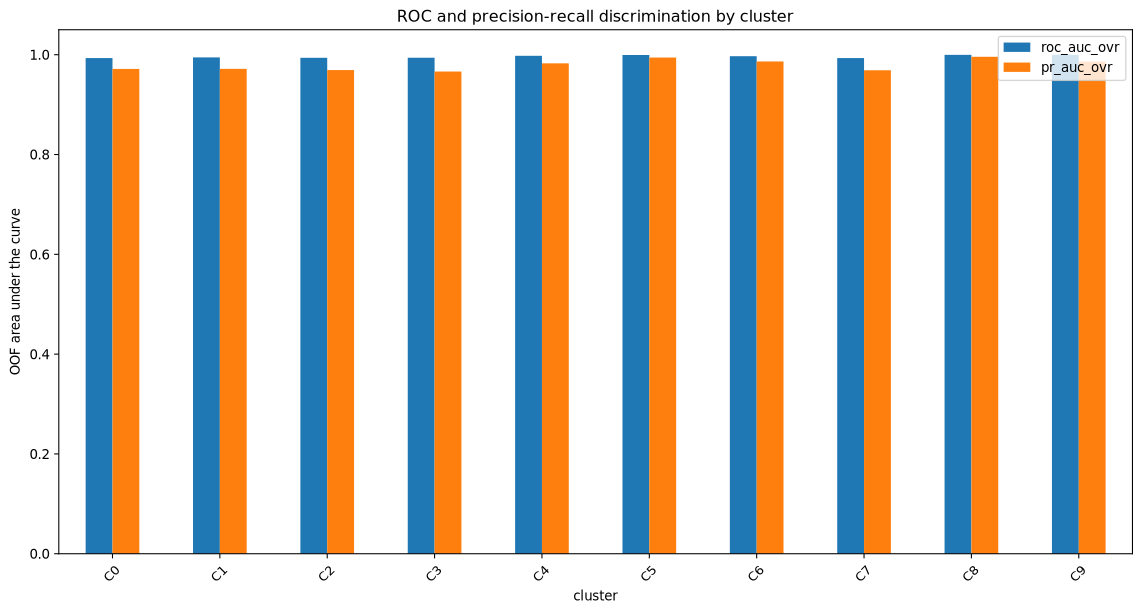

### Figure 4
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

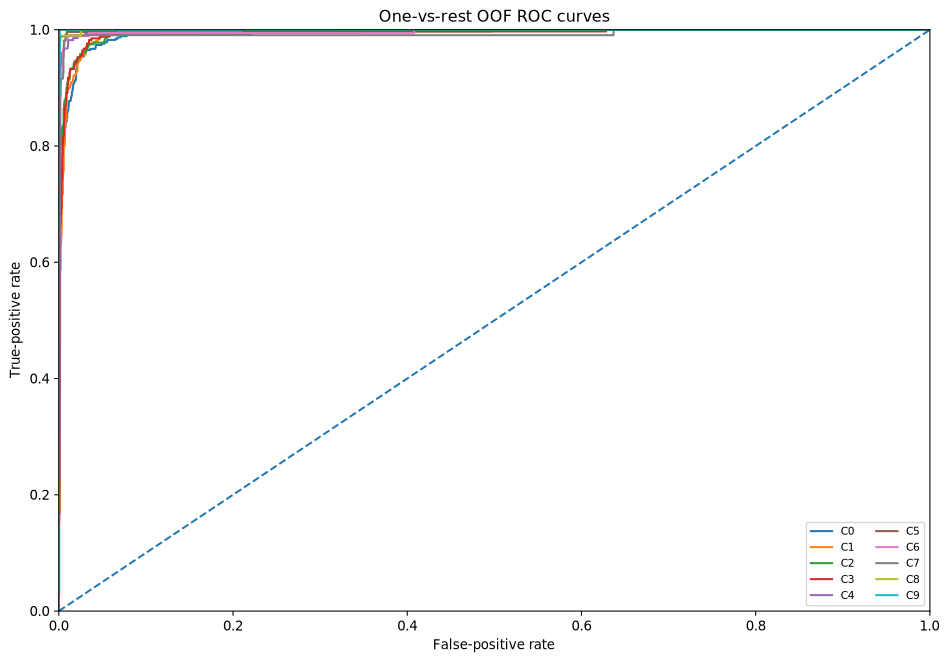

### Figure 5
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

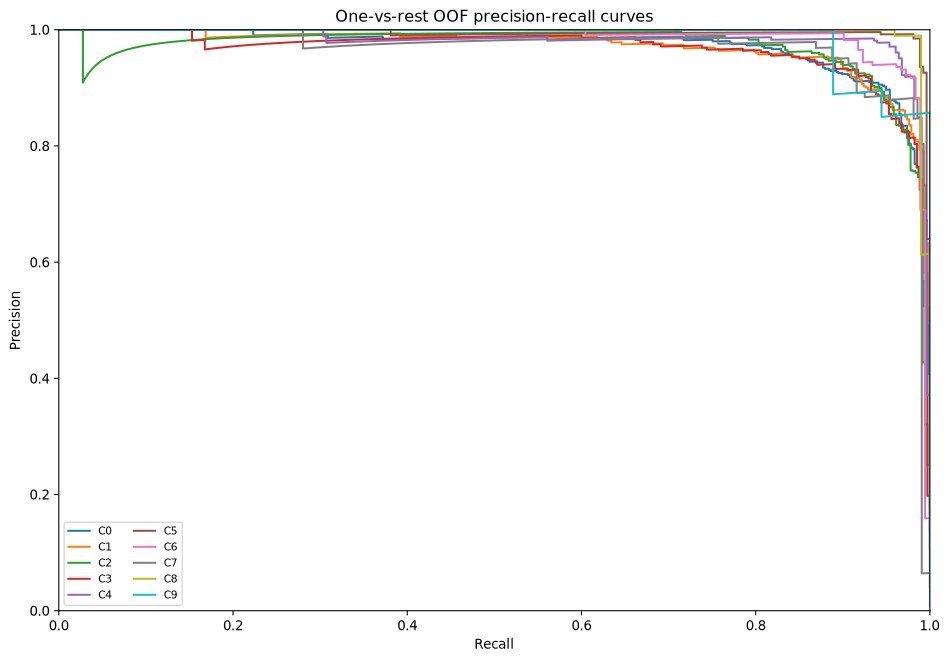

### Figure 6
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

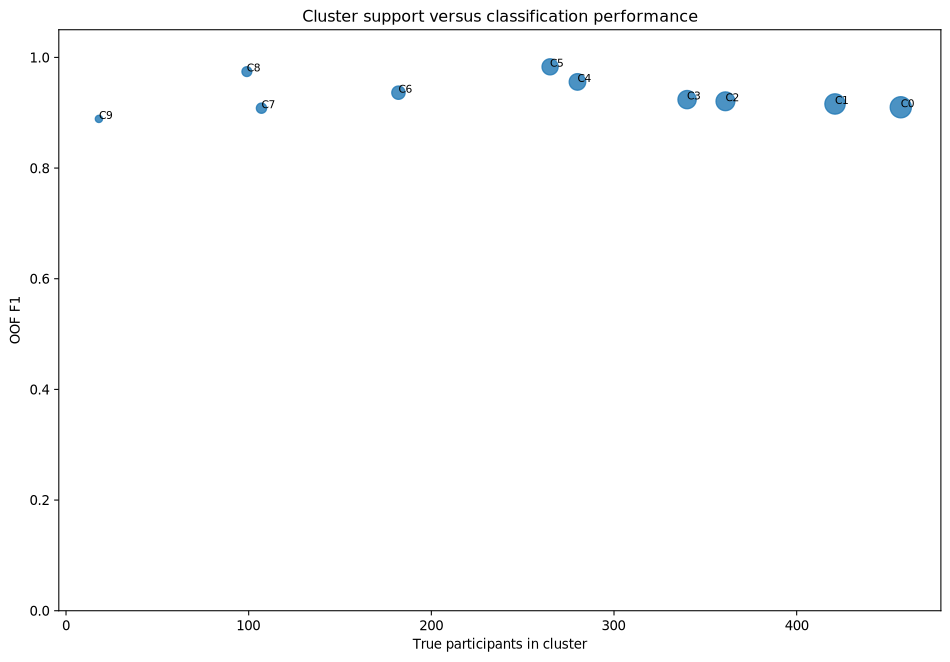

### Figure 7
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

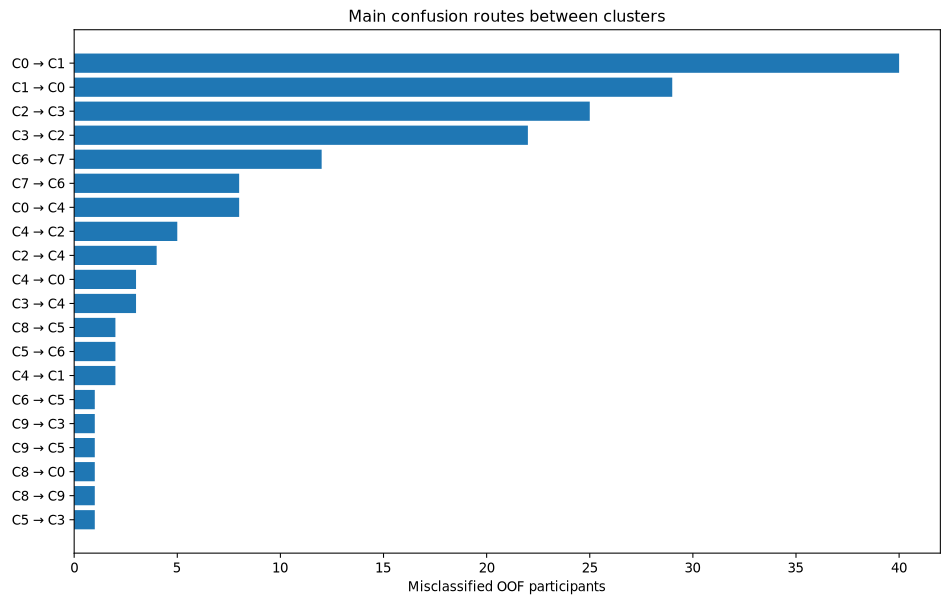

### Figure 8
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

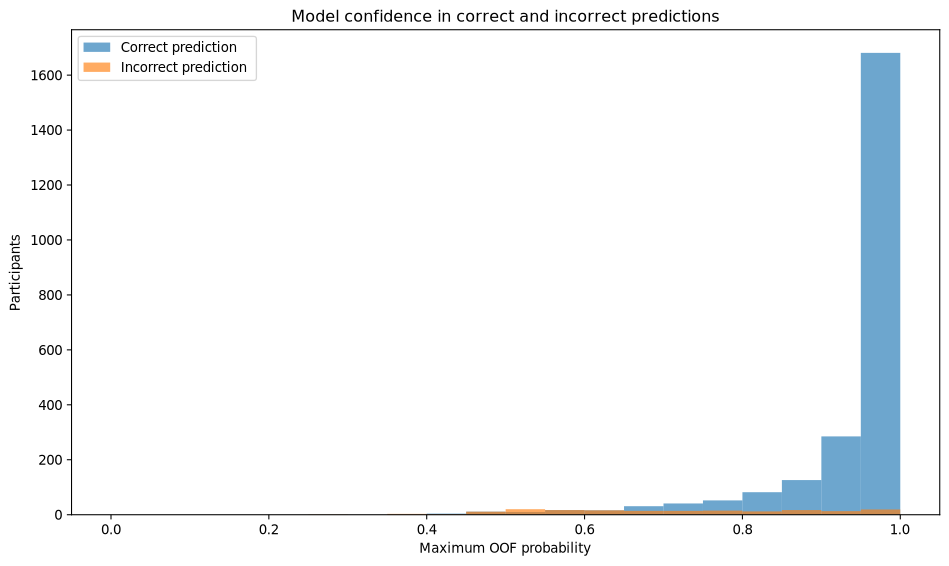

### Figure 9
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

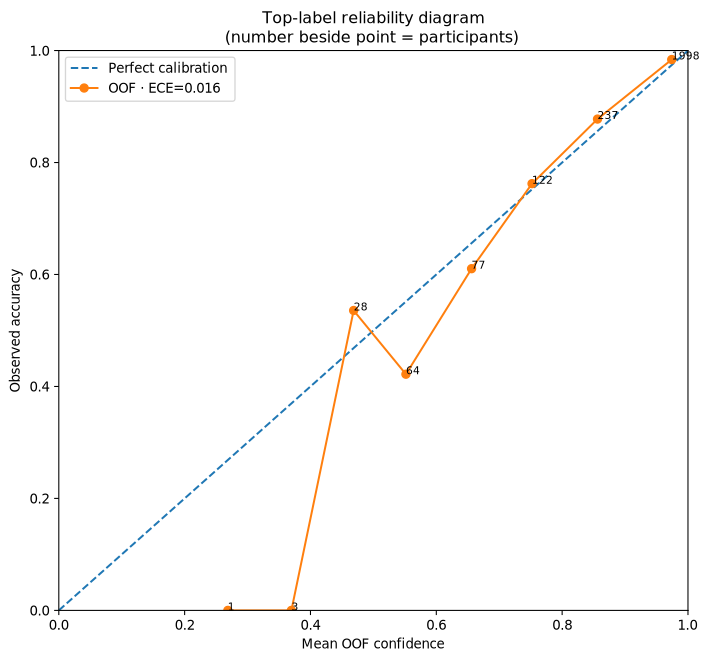

### Figure 10
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

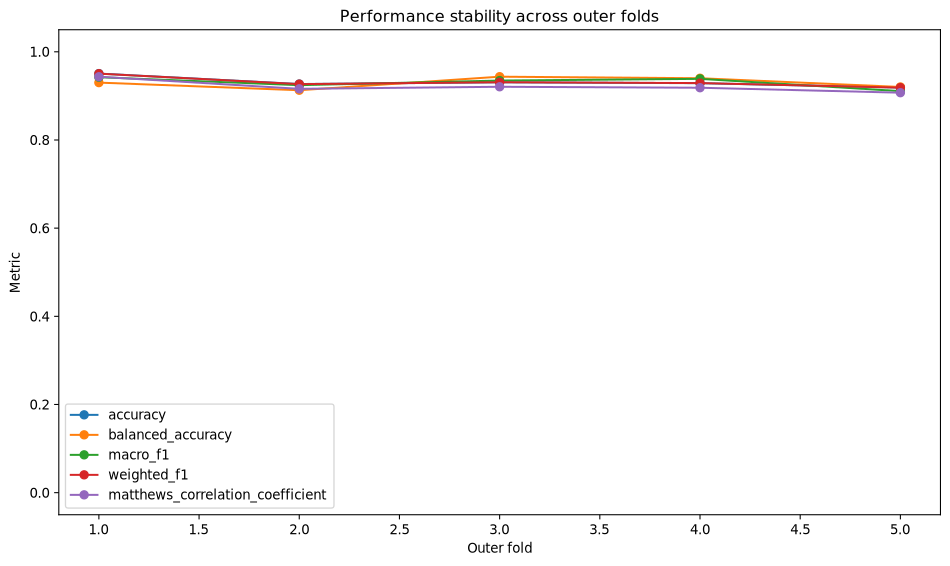

### Figure 11
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

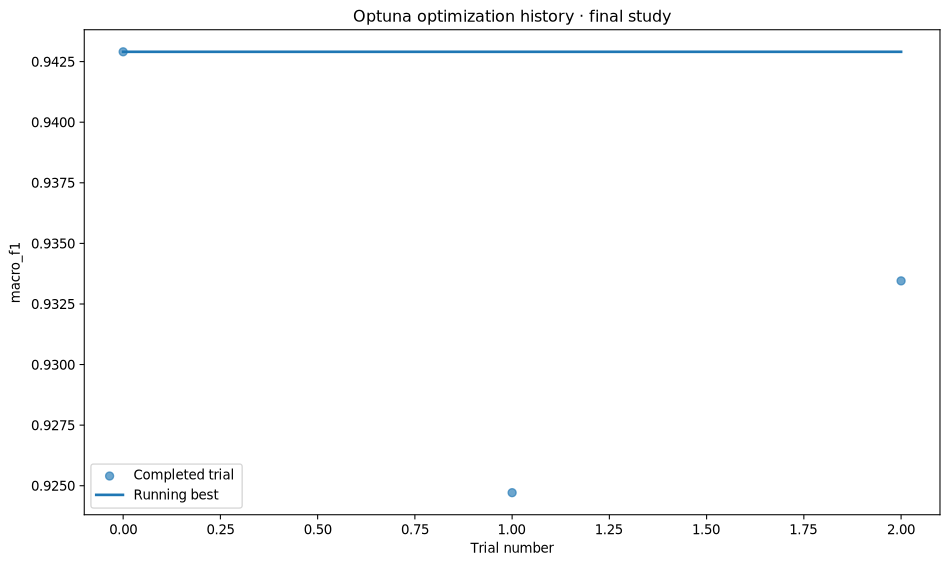

### Figure 12
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

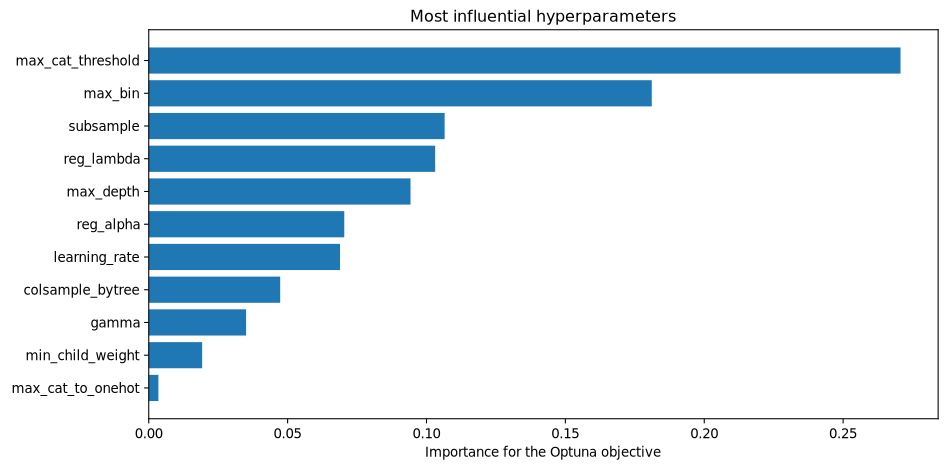

### Figure 13
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

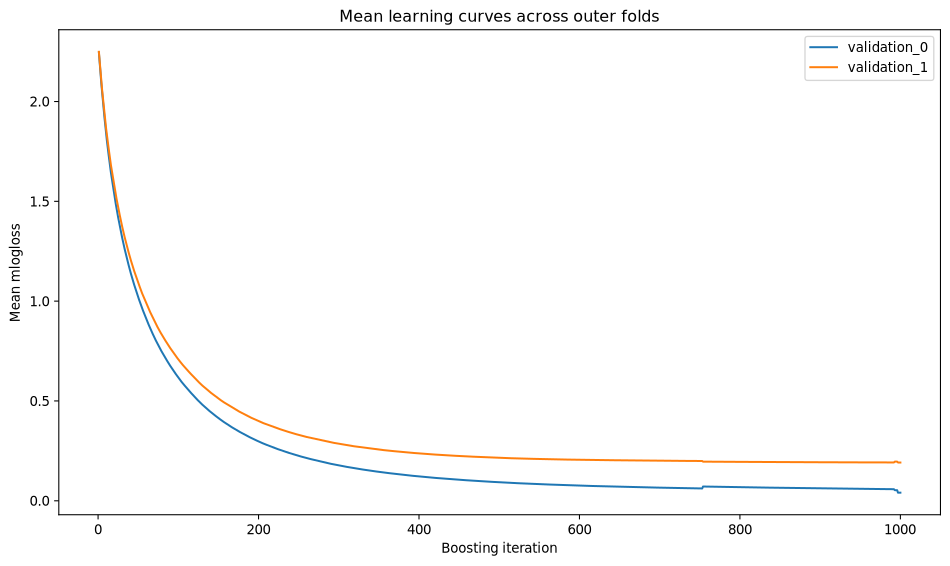

### Figure 14
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

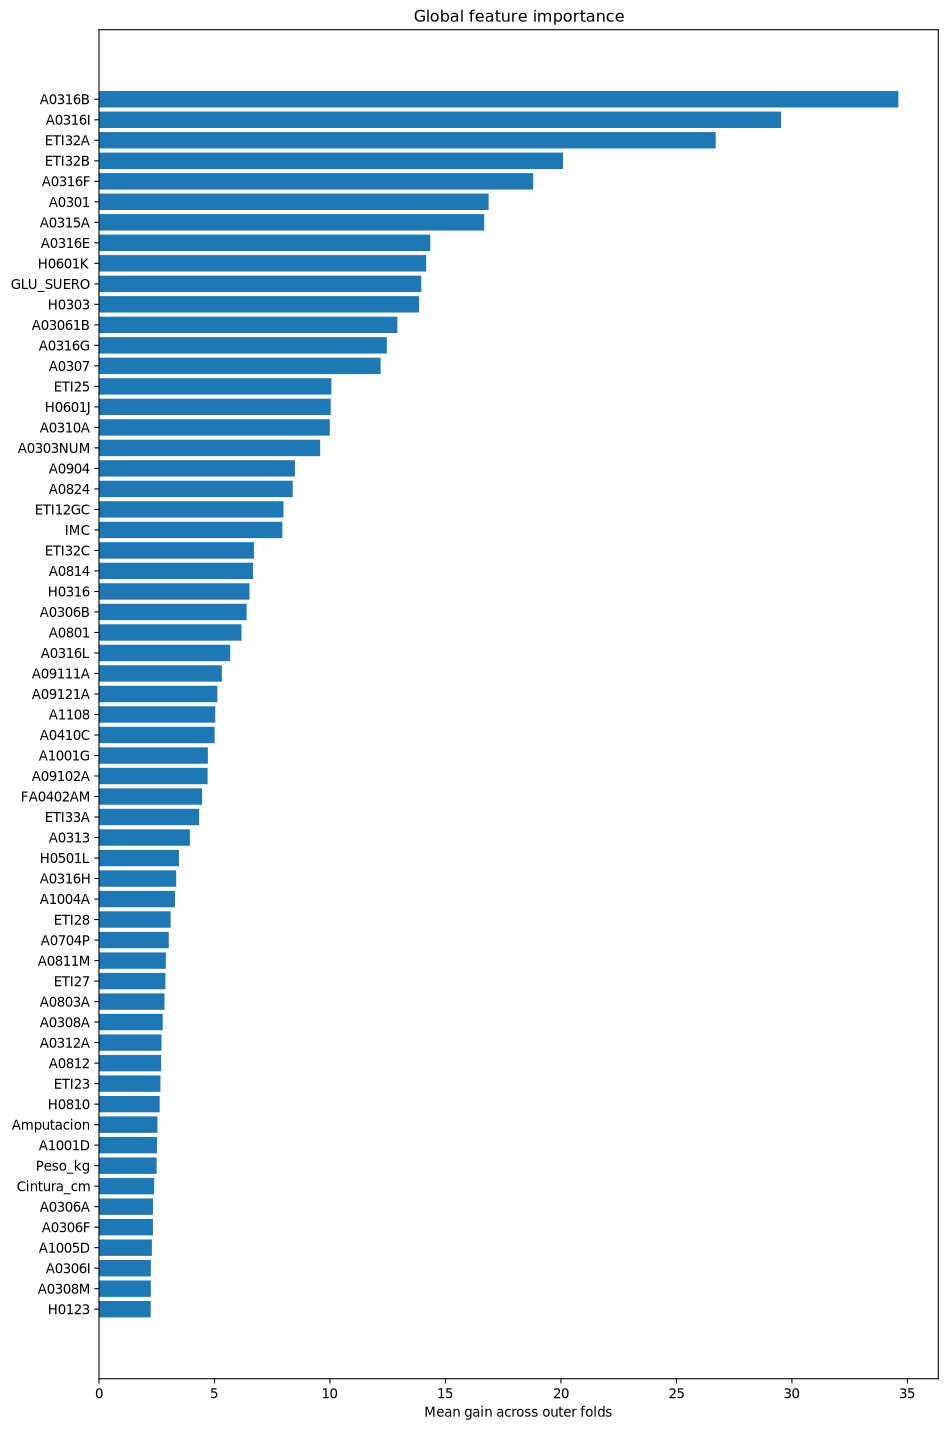

### Figure 15
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

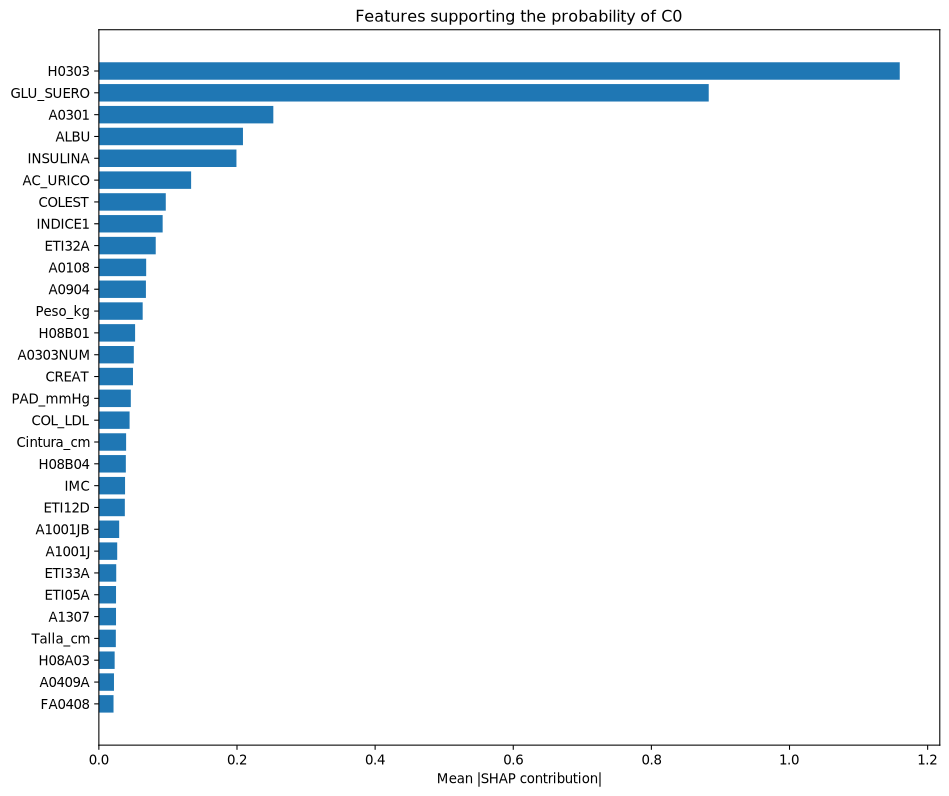

### Figure 16
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

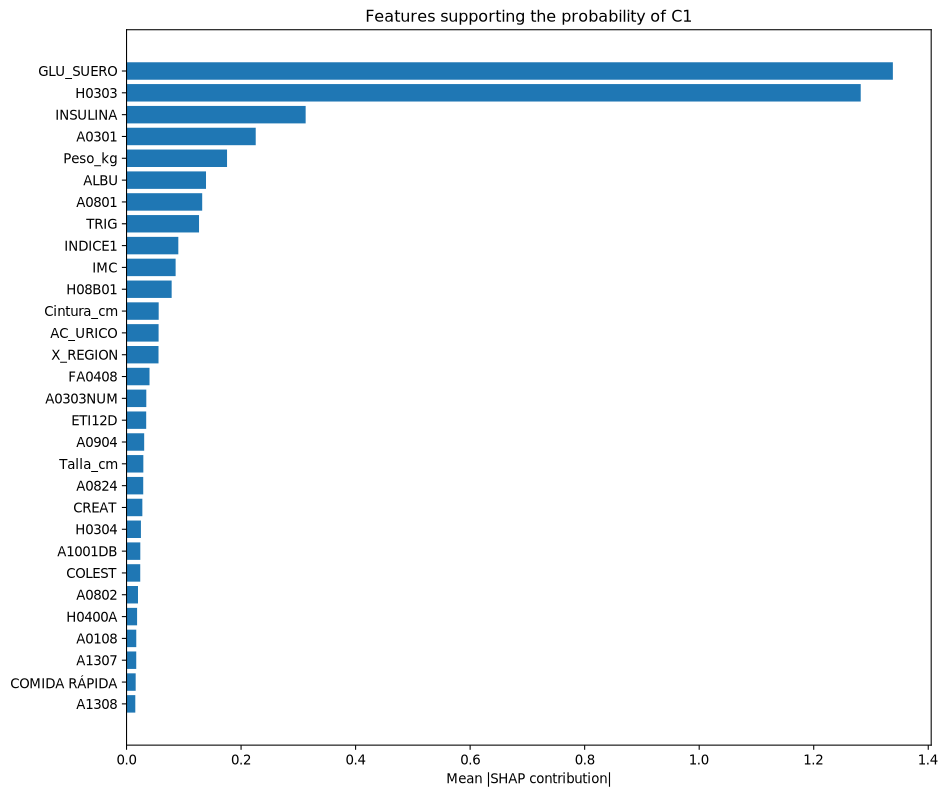

### Figure 17
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

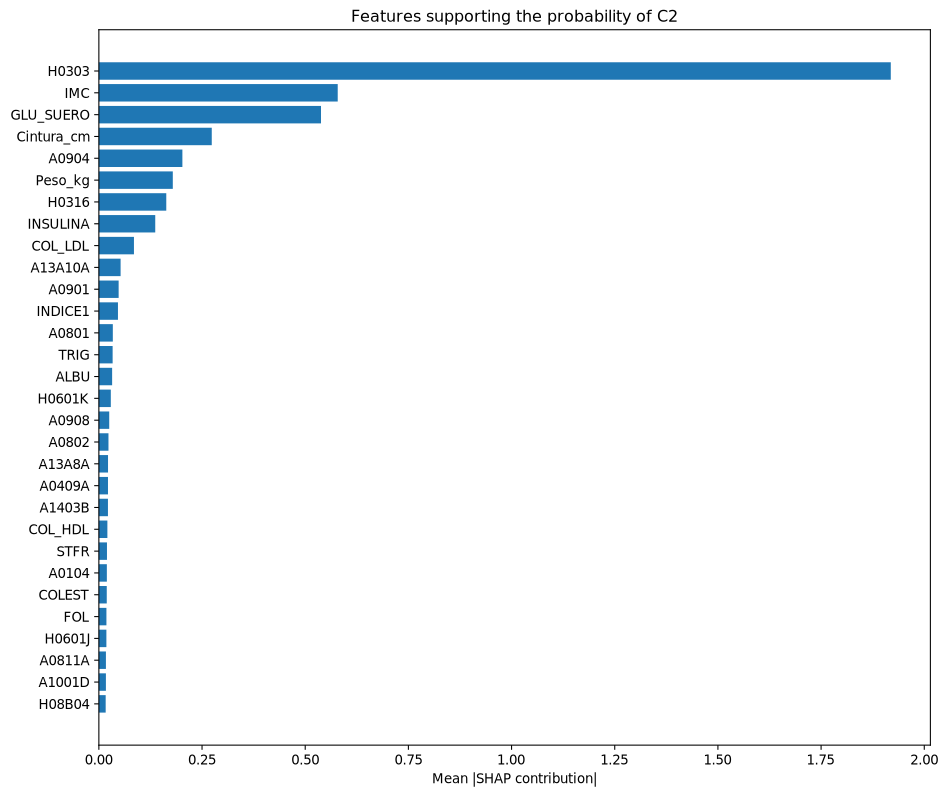

### Figure 18
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

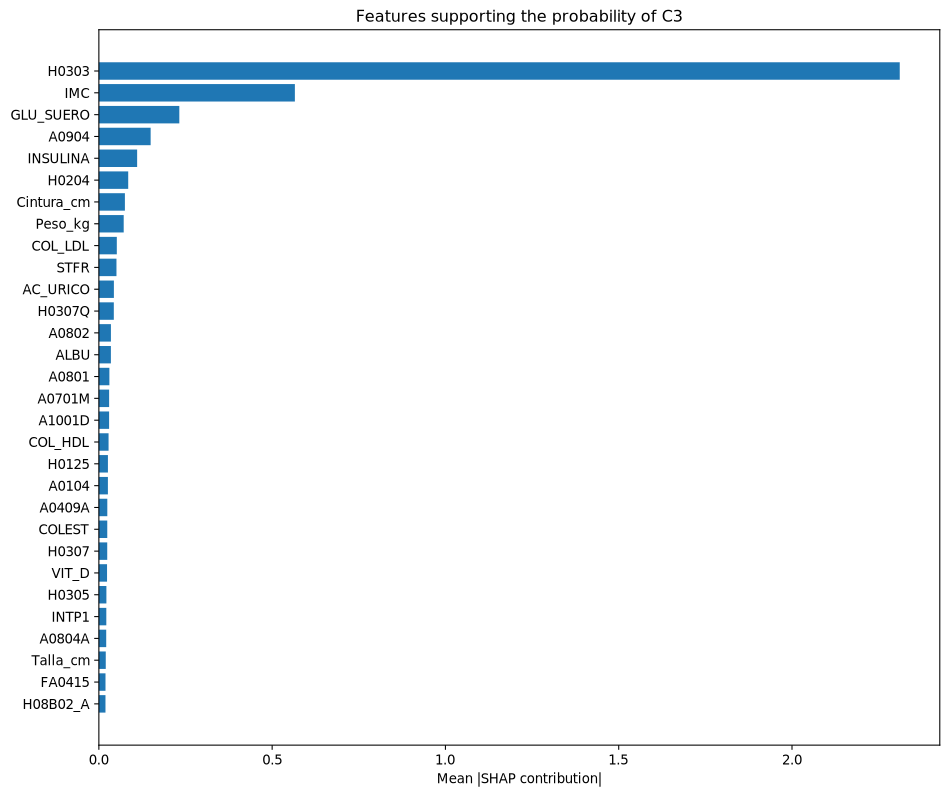

### Figure 19
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

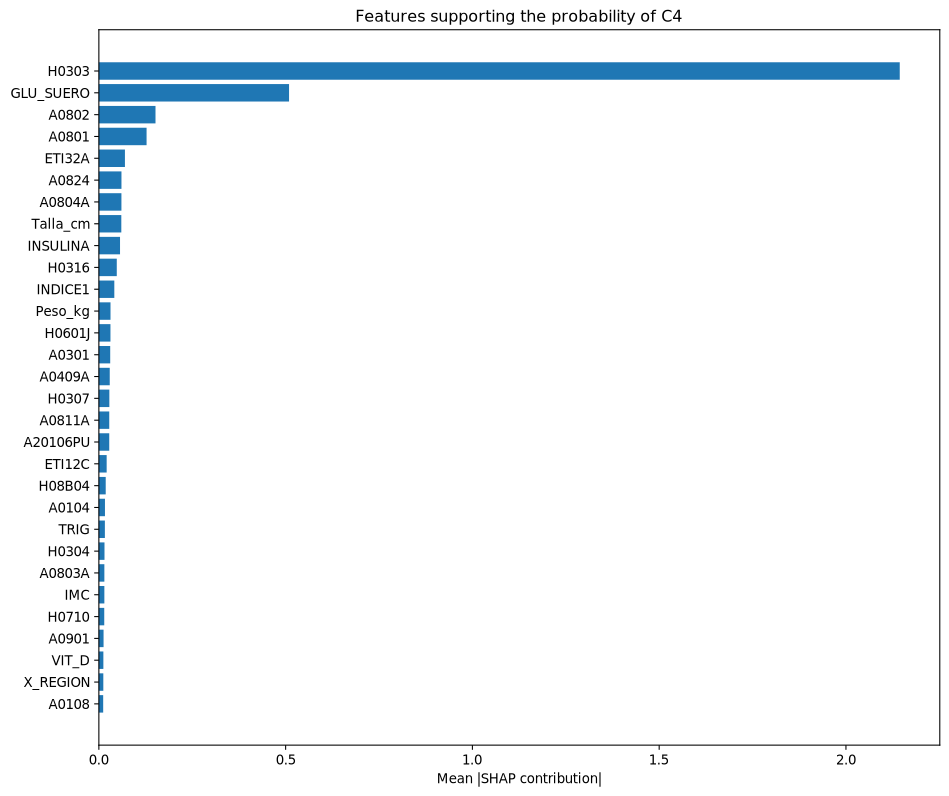

### Figure 20
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

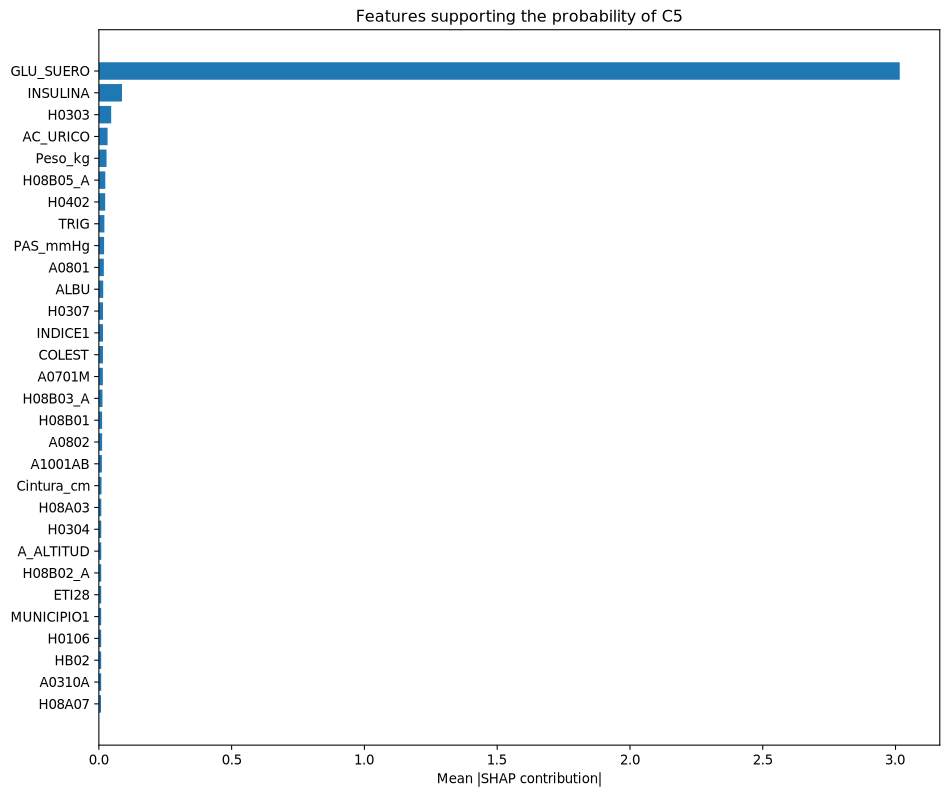

### Figure 21
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

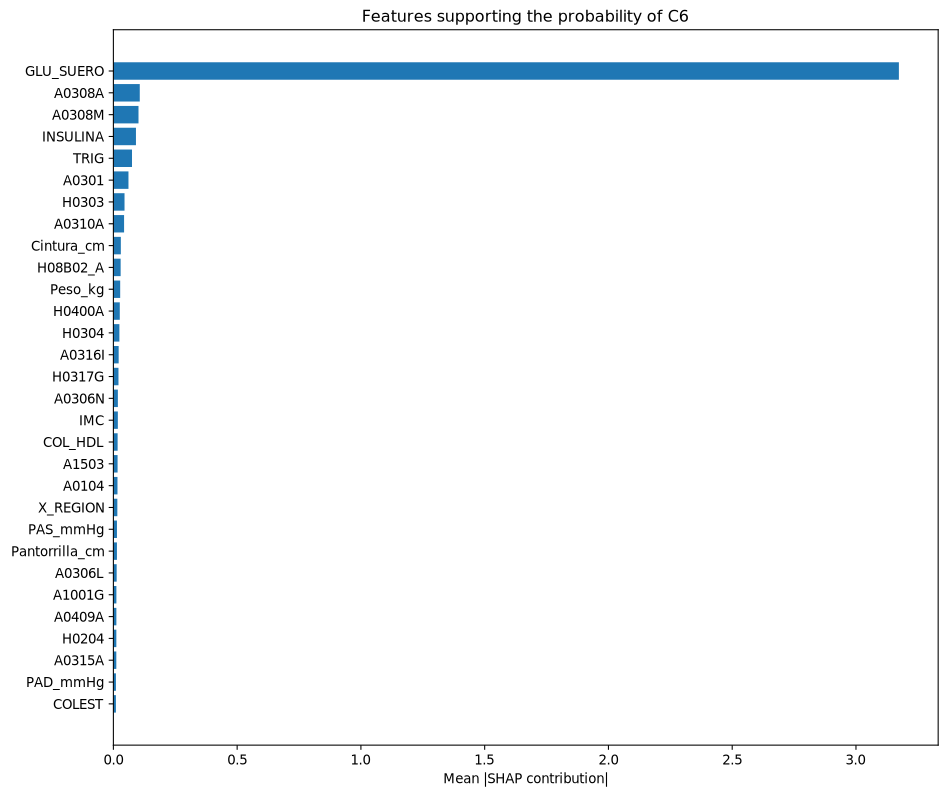

### Figure 22
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

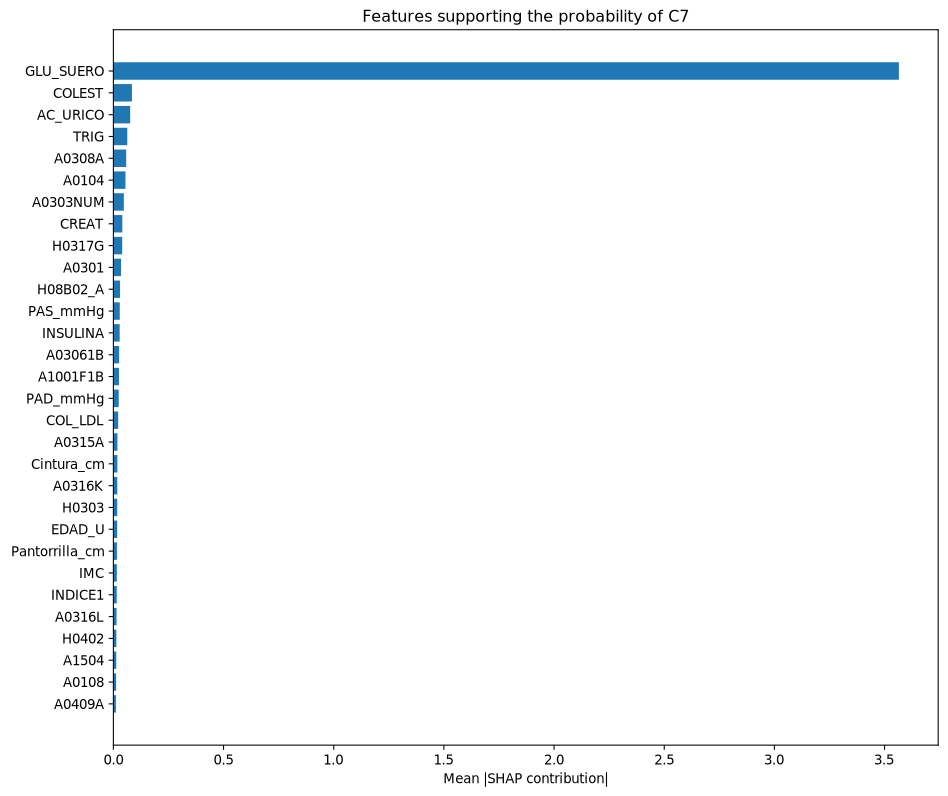

### Figure 23
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

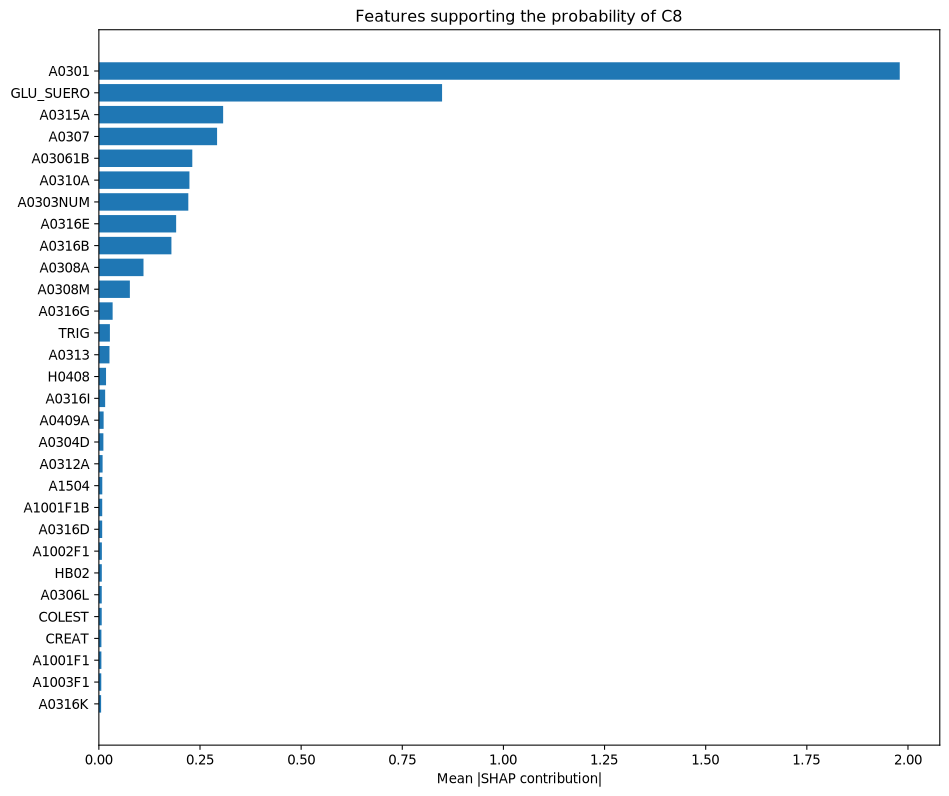

### Figure 24
*From original cell 21: 9. Original 10-cluster XGBoost prediction and complete OOF diagnostics*

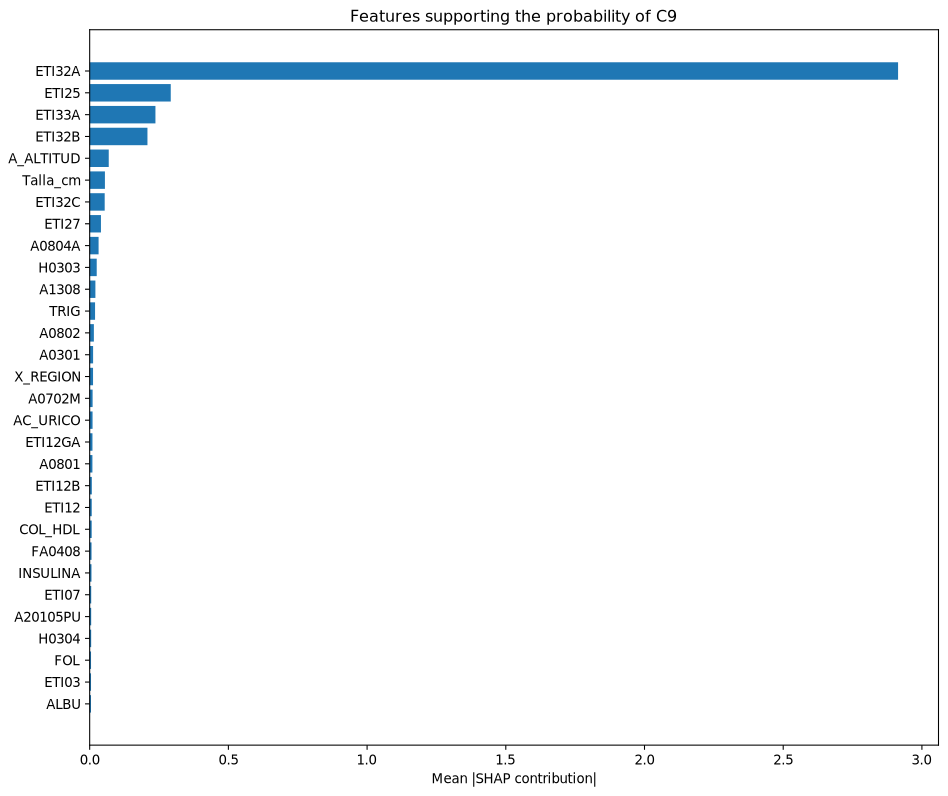

### Figure 25
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

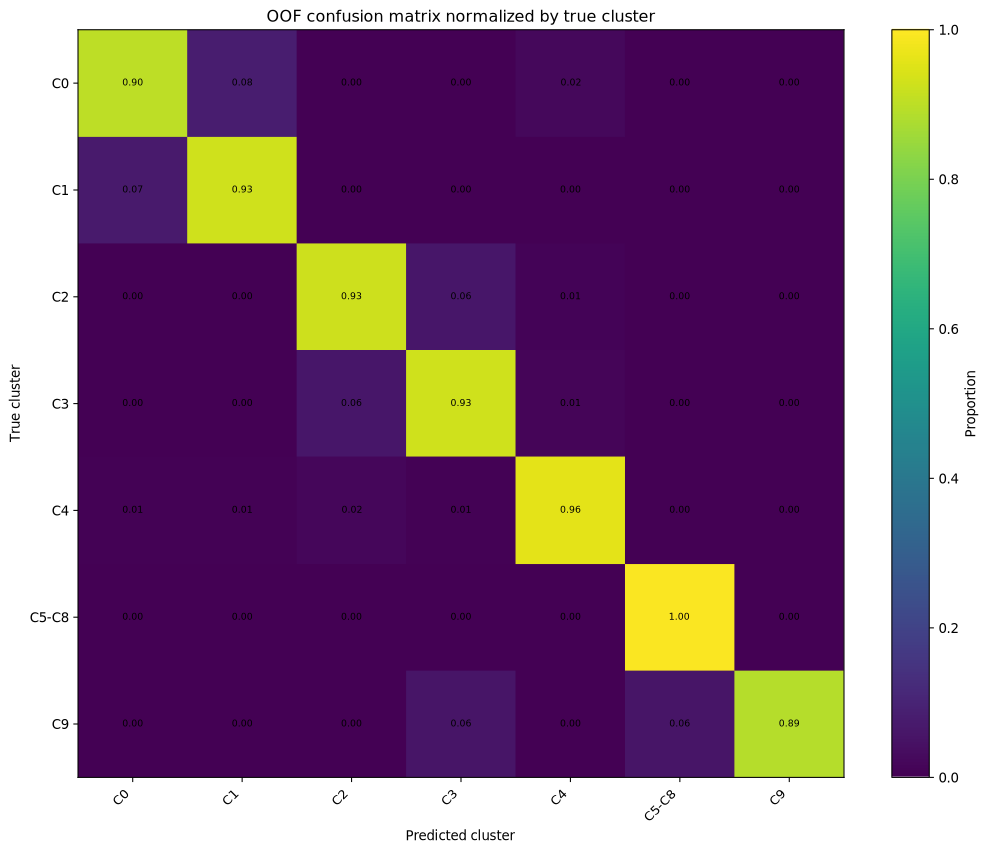

### Figure 26
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

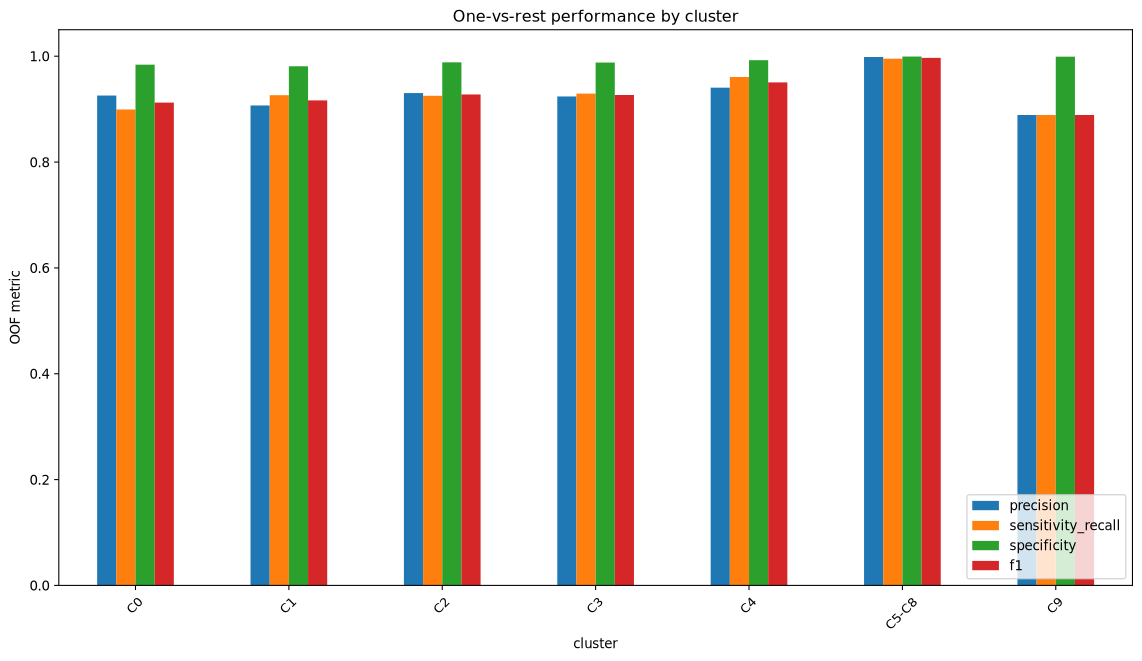

### Figure 27
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

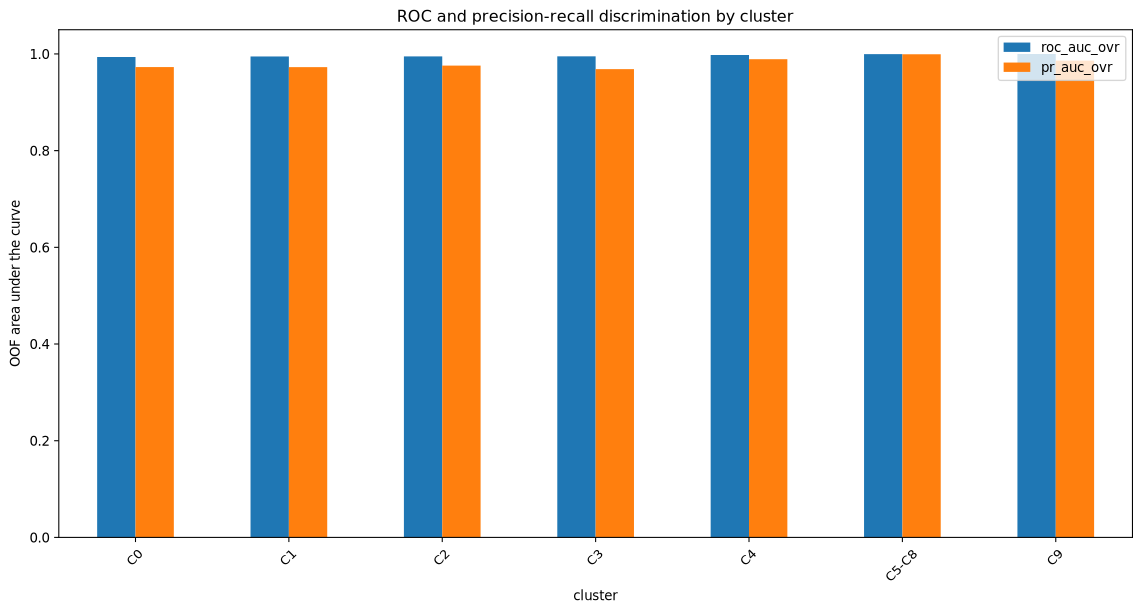

### Figure 28
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

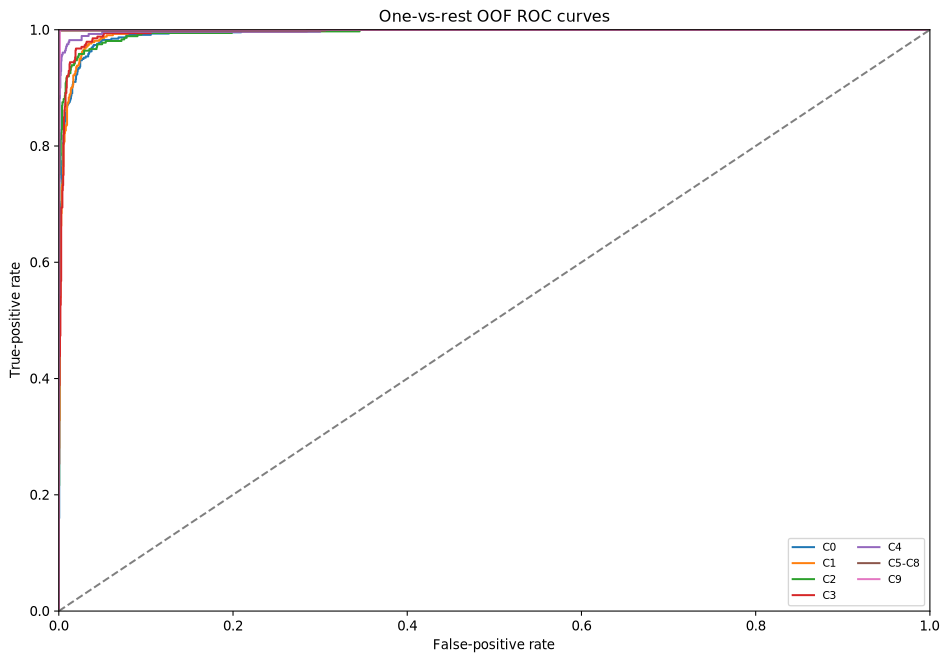

### Figure 29
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

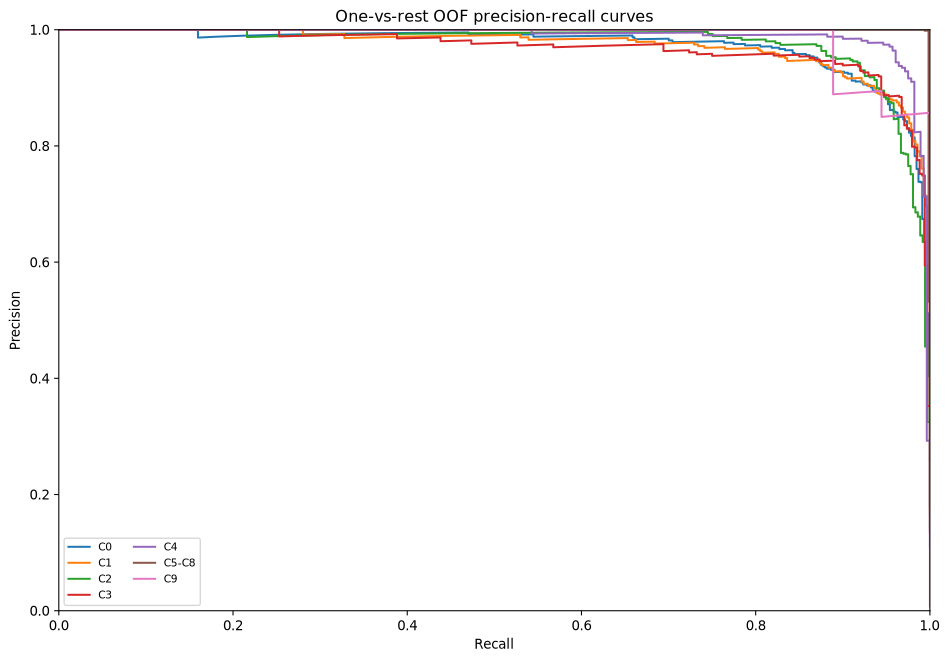

### Figure 30
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

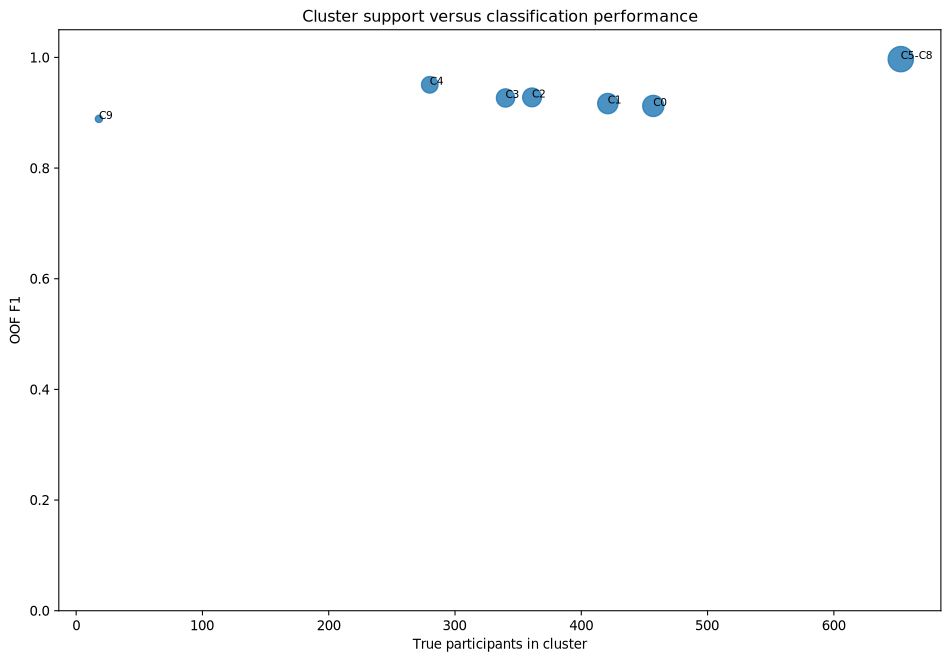

### Figure 31
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

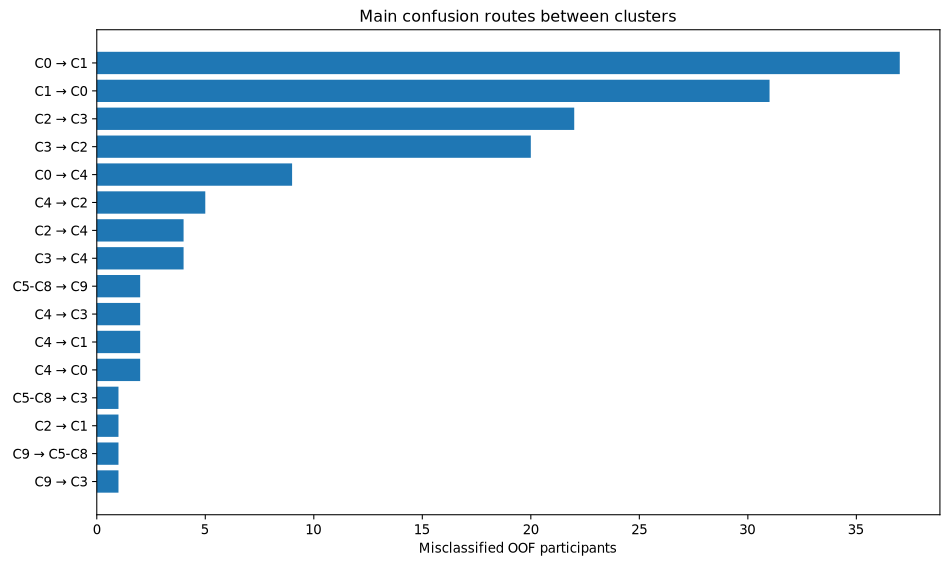

### Figure 32
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

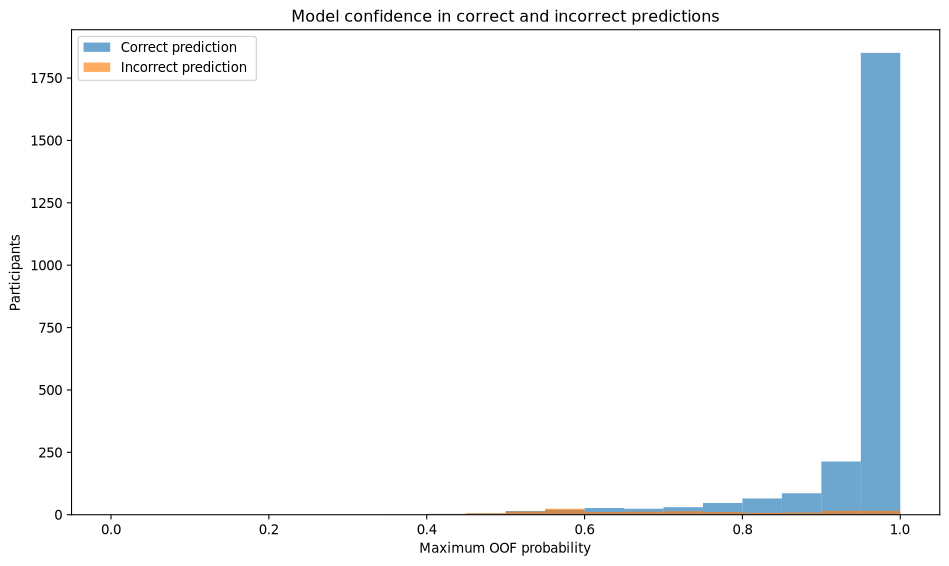

### Figure 33
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

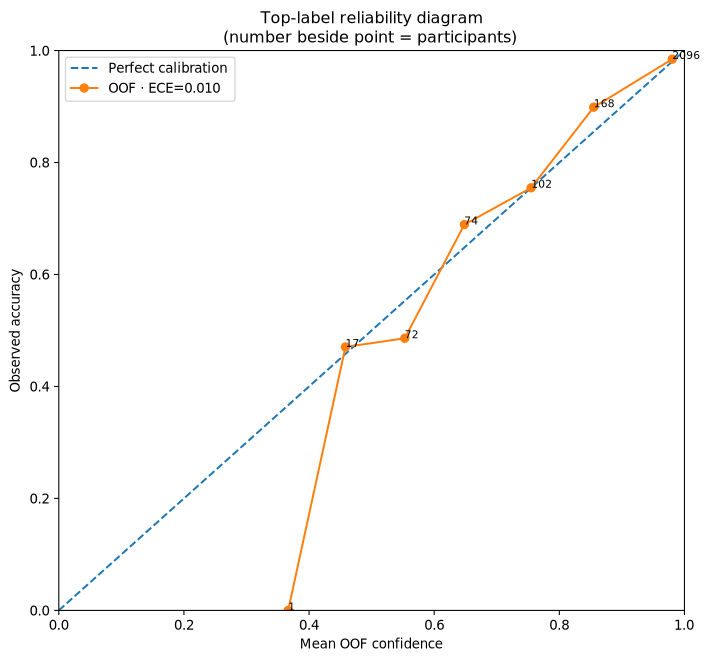

### Figure 34
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

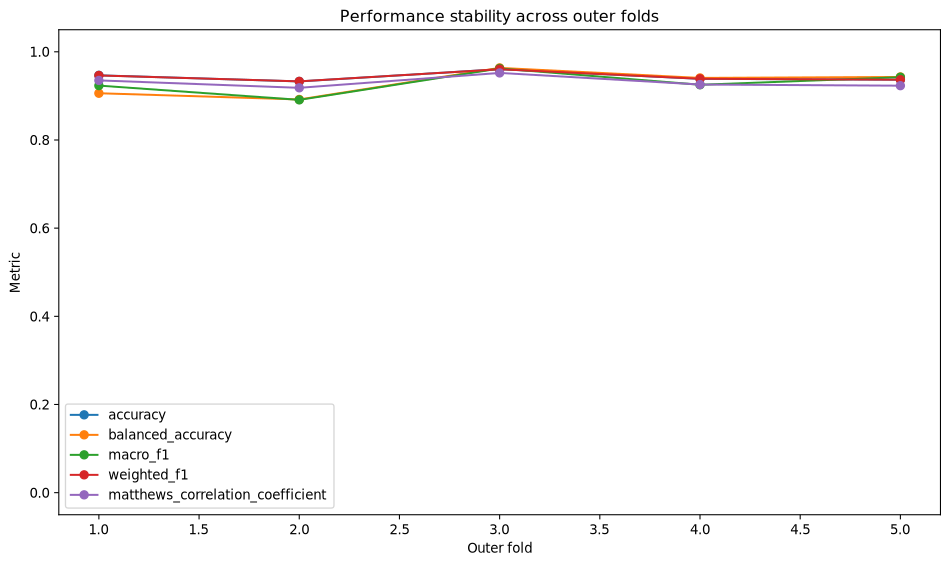

### Figure 35
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

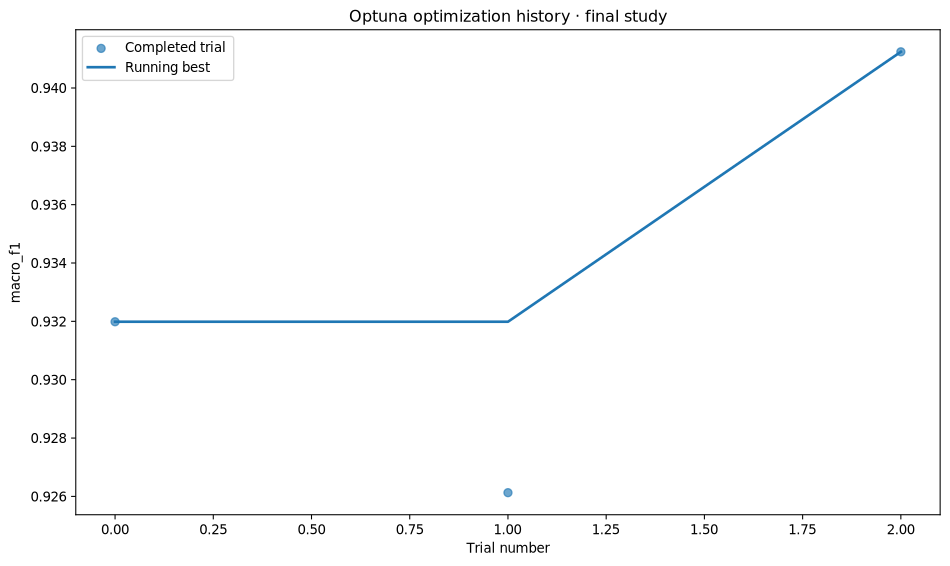

### Figure 36
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

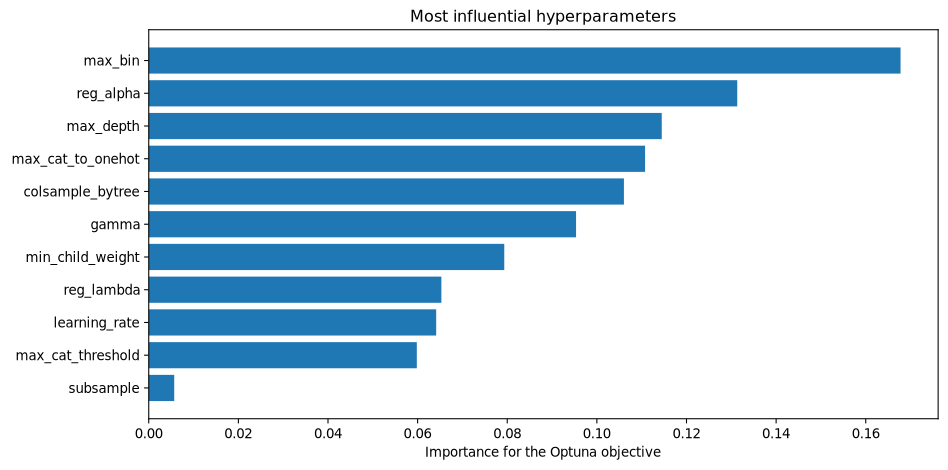

### Figure 37
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

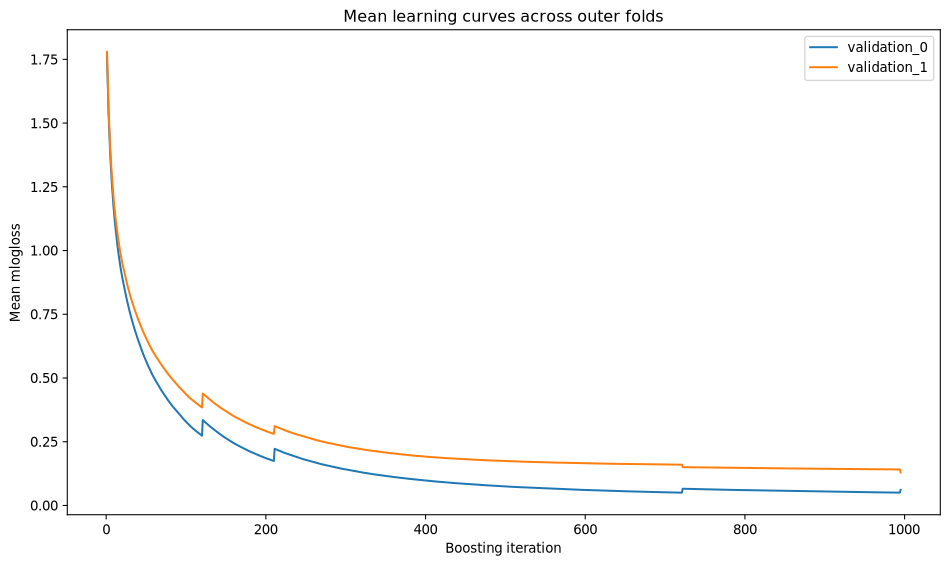

### Figure 38
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

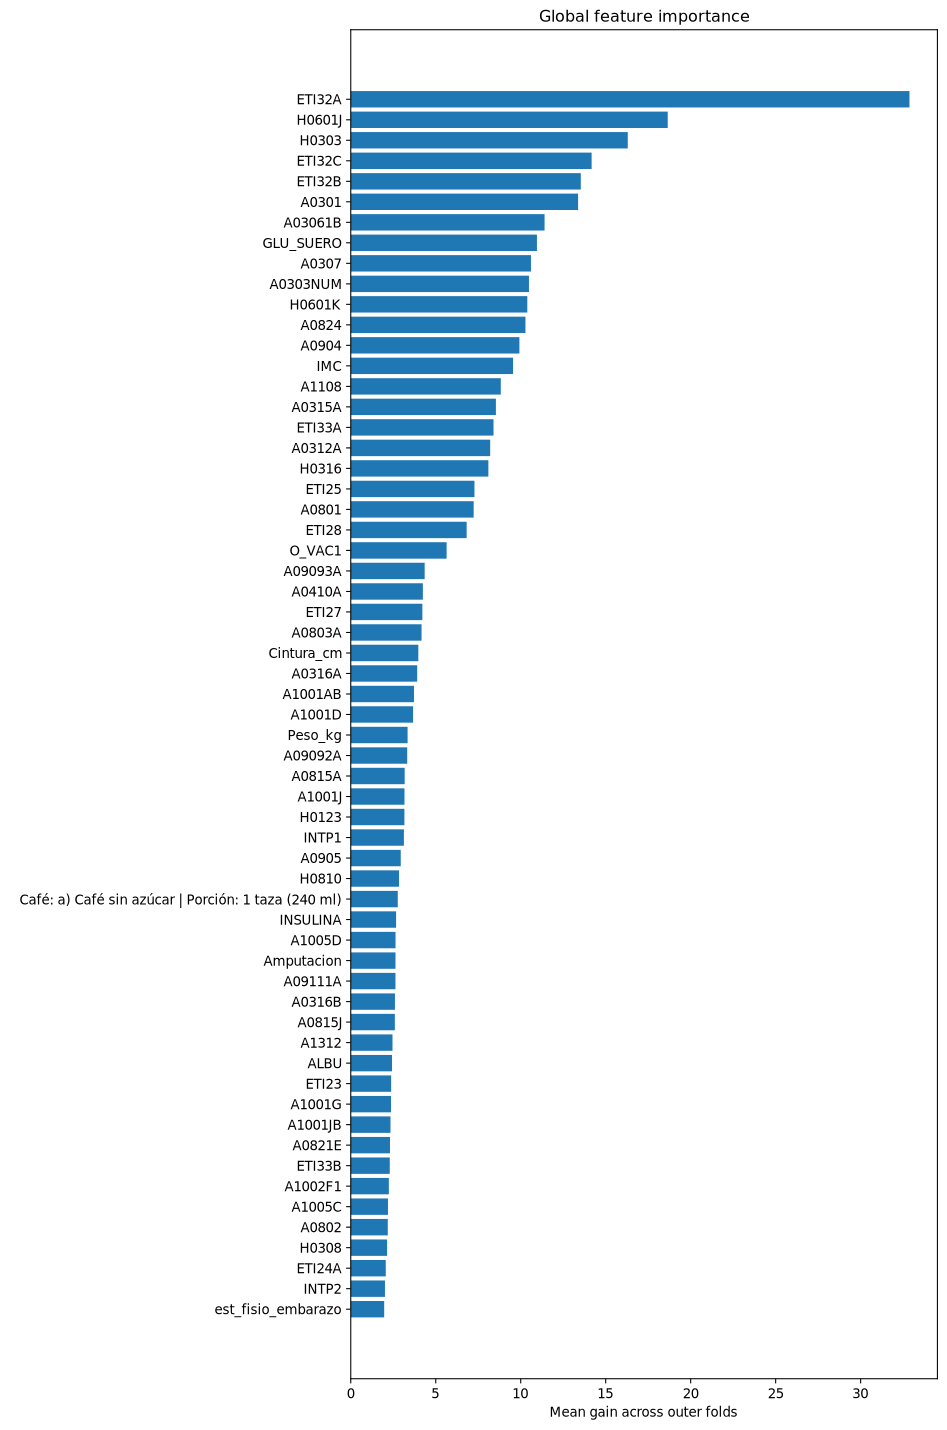

### Figure 39
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

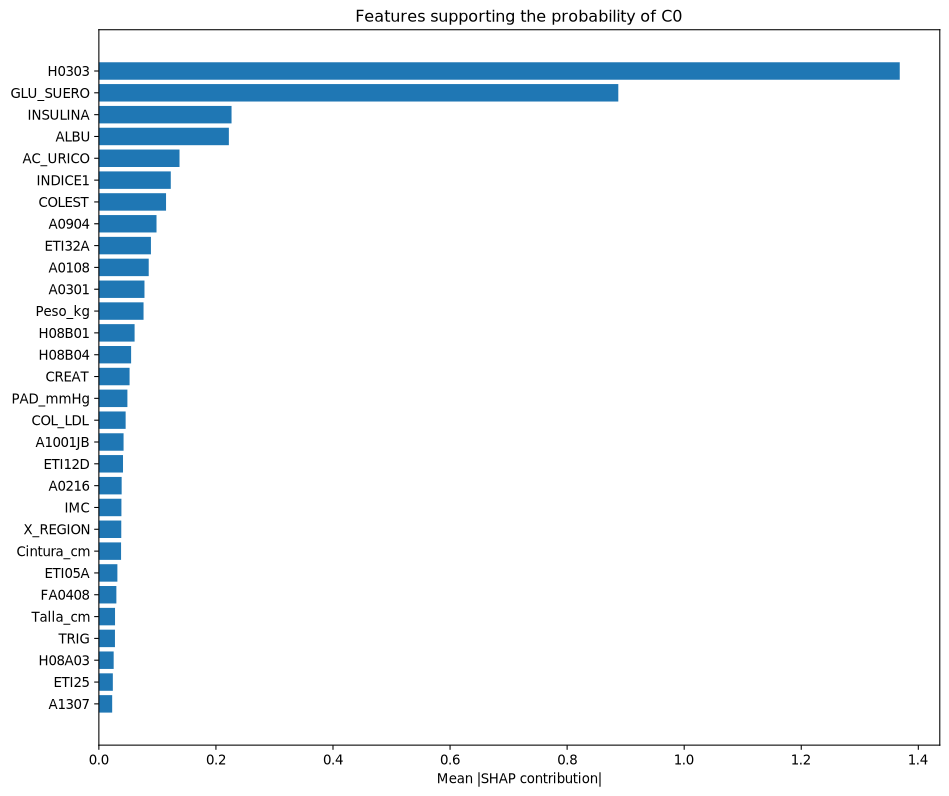

### Figure 40
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

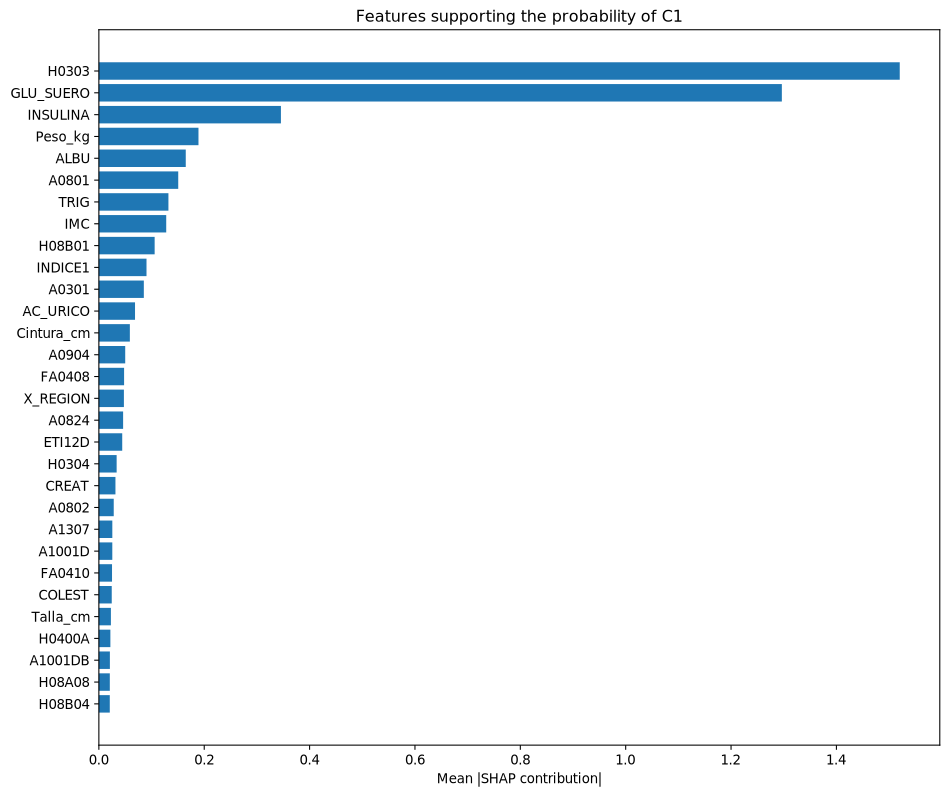

### Figure 41
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

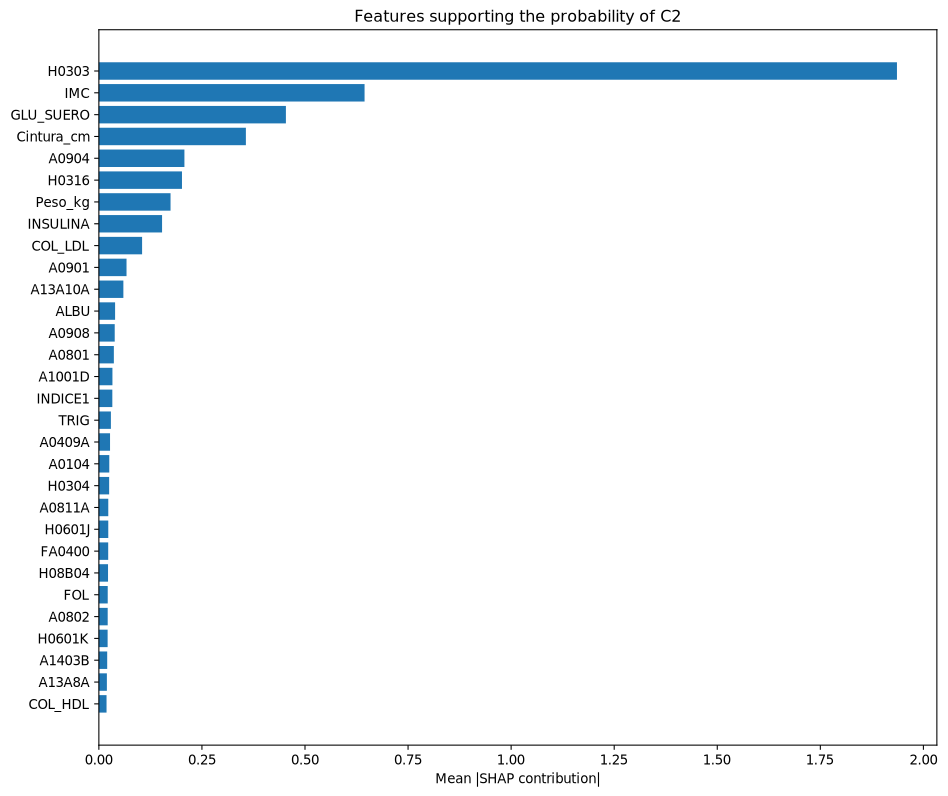

### Figure 42
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

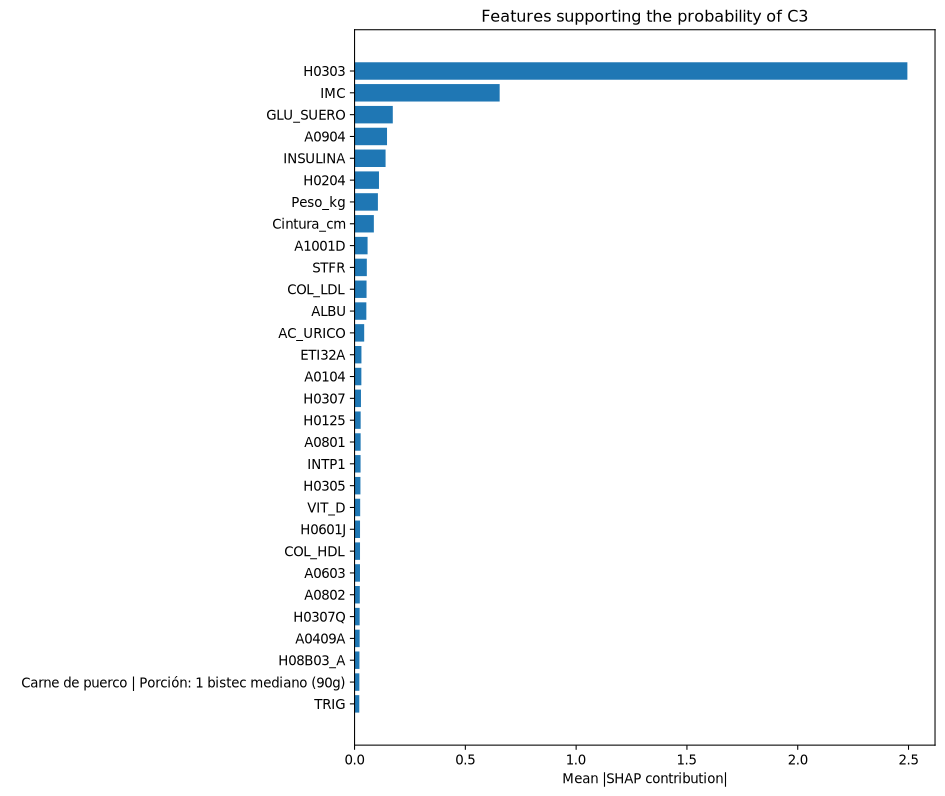

### Figure 43
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

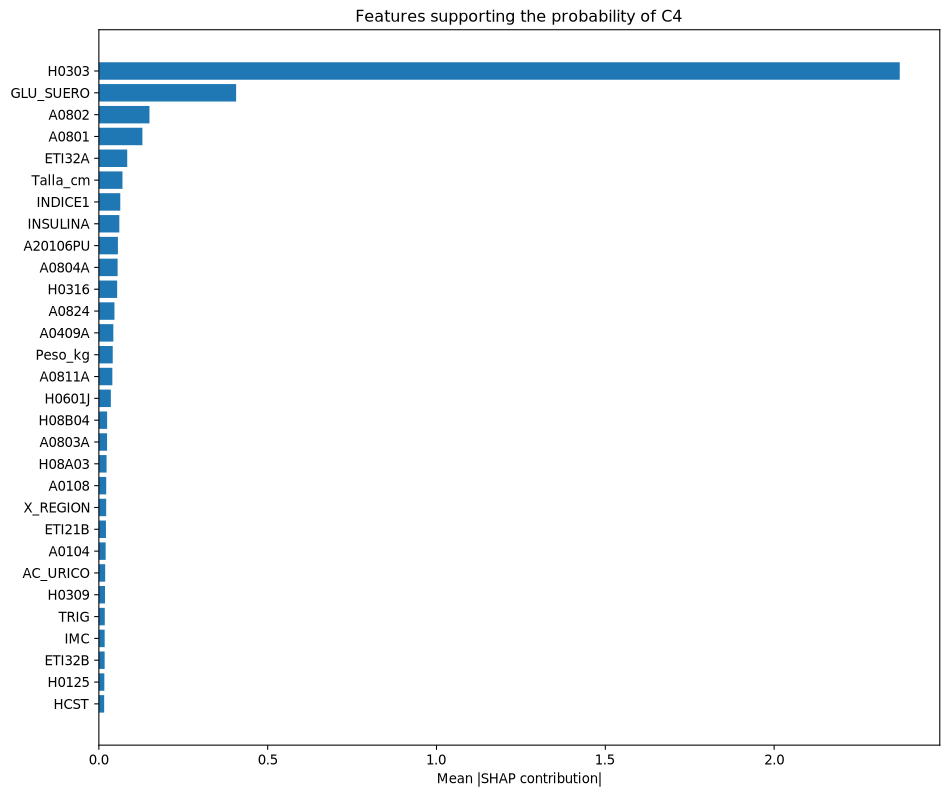

### Figure 44
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

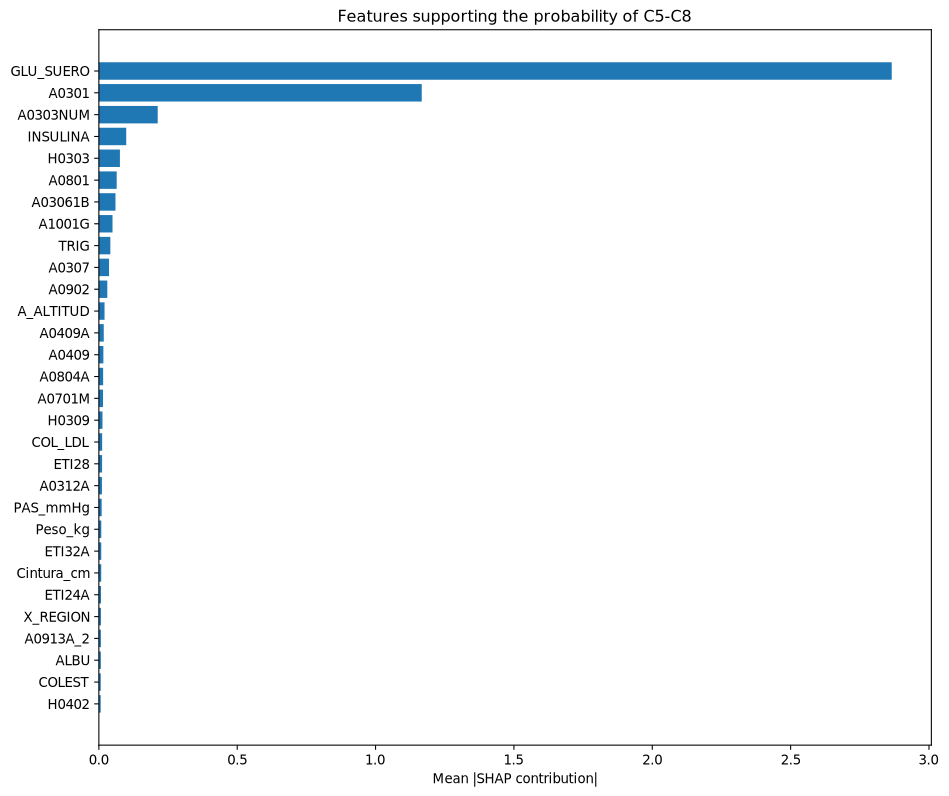

### Figure 45
*From original cell 23: 10. XGBoost prediction after merging C5–C8*

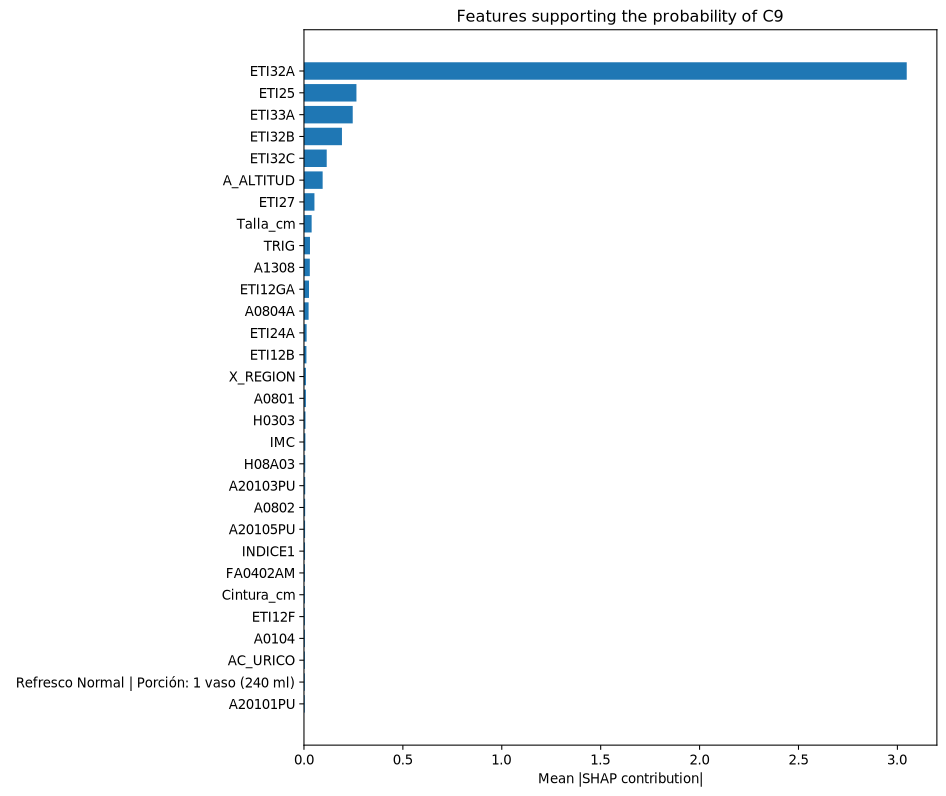

In [ ]:
# PRE-RENDERED FIGURE GALLERY
# Outputs are already embedded; do not run this cell.
